# TFG — DeepColony Pipeline
----
#### BSc Data Science and Engineering
#### Author: Mario Coronado Fernández

**Fixes (v3):**
- Full paper's pipeline

### Necessary Imports

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import pickle
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import v_measure_score, confusion_matrix, ConfusionMatrixDisplay
from collections import defaultdict

# Reproducibility
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


#### Connect to Colab & mount Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

ZIP_PATH   = '/content/drive/MyDrive/TFG/data_tfg.zip'
WORK_DIR   = '/content/data_lab'
OUTPUT_DIR = '/content/drive/MyDrive/TFG/resultados_entrenamiento'

os.makedirs(WORK_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(os.path.join(WORK_DIR, 'metadata.json')):
    print('Descomprimiendo dataset...')
    os.system(f'unzip -q "{ZIP_PATH}" -d "{WORK_DIR}"')
    print('Completado!')
else:
    print('Los datos ya están listos.')

Mounted at /content/drive
Descomprimiendo dataset...
Completado!


---
## Level 2 — Single Colony CNN
### Architecture


In [ ]:
# ==================== SINGLE COLONY CNN ====================
# Paper: Supp. Note 1 — four conv layers, Leaky ReLU, LRN, MaxPool(stride=2)
# Operation order per paper: Conv → LeakyReLU → LRN → MaxPool

class SingleColonyCNN(nn.Module):
    def __init__(self):
        super(SingleColonyCNN, self).__init__()
        # Conv layers (filters match paper exactly)
        self.conv1 = nn.Conv2d(3,   20,  kernel_size=5)  # 128 → 124
        self.conv2 = nn.Conv2d(20,  50,  kernel_size=5)  # → 58 (after pool)
        self.conv3 = nn.Conv2d(50,  100, kernel_size=4)  # → 26 (after pool)
        self.conv4 = nn.Conv2d(100, 200, kernel_size=4)  # → 10 (after pool)

        # LRN and MaxPool are shared across all conv blocks
        # Paper: 'outputs of Leaky ReLU activations are normalized using LRN'
        # Paper: 'non-overlapping max-pooling layer with stride equal to 2'
        self.lrn     = nn.LocalResponseNorm(size=5)
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)  # non-overlapping

        # FC layers
        # After 4x (conv + pool): 128→62→29→13→5, so 200*5*5 = 5000
        self.dropout = nn.Dropout(p=0.75)   # paper: dropout rate 0.75
        self.fc1     = nn.Linear(200 * 5 * 5, 500)
        self.fc2     = nn.Linear(500, 32)   # 32 species

    def _conv_block(self, x, conv_layer):
        """Single conv block in paper-specified order:
           Conv → LeakyReLU (slope=0.01) → LRN → MaxPool(stride=2)
        """
        x = conv_layer(x)
        x = F.leaky_relu(x, negative_slope=0.01)
        x = self.lrn(x)
        x = self.pool(x)
        return x

    def forward(self, x, _check_shape=False):
      x = self._conv_block(x, self.conv1)
      x = self._conv_block(x, self.conv2)
      x = self._conv_block(x, self.conv3)
      x = self._conv_block(x, self.conv4)

      if _check_shape:
        assert x.shape[1:] == (200, 5, 5), f'Unexpected shape: {x.shape}'
        print(f'  Shape check passed: {tuple(x.shape[1:])}')

      x = x.view(x.size(0), -1)
      x = self.dropout(x)                                        # before fc1
      x = F.leaky_relu(self.fc1(x), negative_slope=0.01)
      return self.fc2(x)

    def get_pIDv(self, x):
        """Returns softmax probability vector (pIDv) — use at inference time only."""
        self.eval()
        with torch.no_grad():
            return torch.softmax(self.forward(x), dim=1)


# ==================== ADAPTIVE PADDING ====================
# Pads colony crops to square + margin BEFORE resizing.
# This preserves absolute colony size (a discriminative feature per paper).
class AdaptivePadding:
    def __init__(self, margin=20, fill=0):
        self.margin = margin
        self.fill   = fill

    def __call__(self, img):
        w, h     = img.size
        max_side = max(w, h)
        pad_w    = max_side - w + self.margin
        pad_h    = max_side - h + self.margin
        padding  = (pad_w // 2, pad_h // 2,
                    pad_w - pad_w // 2, pad_h - pad_h // 2)
        return transforms.functional.pad(img, padding, fill=self.fill)


# Check on architecture dimensions
with torch.no_grad():
    _dummy = torch.randn(2, 3, 128, 128)
    _m     = SingleColonyCNN()
    _out   = _m(_dummy, _check_shape=True)
    print(f'  Output logits shape: {_out.shape}  (expected (2, 32))')
    del _dummy, _m, _out
print('SingleColonyCNN architecture OK.')

  Shape check passed: (200, 5, 5)
  Output logits shape: torch.Size([2, 32])  (expected (2, 32))
SingleColonyCNN architecture OK.


### Dataset

In [ ]:
# ==================== COLONY DATASET ====================
class ColonyDataset(Dataset):
    def __init__(self, metadata_path, dataset_path, transform=None,
                 species_to_idx=None):
        with open(metadata_path, 'r') as f:
            data = json.load(f)
        self.metadata     = list(data['patch_list'].values())
        self.dataset_path = dataset_path
        self.transform    = transform

        # Build mapping from the FULL dataset so every subset shares
        # identical label indices — critical for multi-run consistency.
        if species_to_idx is None:
            unique_species      = sorted(set(item['species'] for item in self.metadata))
            self.species_to_idx = {sp: i for i, sp in enumerate(unique_species)}
        else:
            self.species_to_idx = species_to_idx

        self.idx_to_species = {i: sp for sp, i in self.species_to_idx.items()}

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        item = self.metadata[idx]
        try:
            image = Image.open(
                os.path.join(self.dataset_path, item['filename'])
            ).convert('RGB')
        except Exception:
            image = Image.new('RGB', (128, 128))
        if self.transform:
            image = self.transform(image)
        return image, self.species_to_idx[item['species']]

### Plate-Aware Train / Val Split

The paper splits at the **plate level**, not the colony level.
Splitting randomly by colony index causes data leakage: the model may see colonies from the
same plate in both train and val, inflating validation accuracy.

This function groups colony indices by `plate_n`, shuffles **plates**, then assigns whole
plates to train or val — guaranteeing zero overlap at the colony level.

In [ ]:
def make_plate_aware_split(full_dataset, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    3-way plate-aware split: train / val / test.
    Paper: '60/20/20 subdivision performed at the plate level.'

    Returns:
        tr_idx, va_idx, te_idx : lists of integer indices into the dataset
        train_plates, val_plates, test_plates : sets of plate_n strings
    """
    rng = random.Random(seed)

    plate_to_indices = defaultdict(list)
    for i, item in enumerate(full_dataset.metadata):
        plate_to_indices[item['plate_n']].append(i)

    plates = list(plate_to_indices.keys())
    rng.shuffle(plates)

    n_test  = int(len(plates) * test_ratio)
    n_val   = int(len(plates) * val_ratio)

    test_pls  = set(plates[:n_test])
    val_pls   = set(plates[n_test : n_test + n_val])
    train_pls = set(plates[n_test + n_val:])

    tr_idx = [i for p in train_pls for i in plate_to_indices[p]]
    va_idx = [i for p in val_pls   for i in plate_to_indices[p]]
    te_idx = [i for p in test_pls  for i in plate_to_indices[p]]

    # Sanity: zero overlap
    assert len(set(tr_idx) & set(va_idx)) == 0, 'BUG: train/val overlap!'
    assert len(set(tr_idx) & set(te_idx)) == 0, 'BUG: train/test overlap!'
    assert len(set(va_idx) & set(te_idx)) == 0, 'BUG: val/test overlap!'

    print(f'Plate-aware 3-way split:')
    print(f'  Total plates : {len(plates)}')
    print(f'  Train plates : {len(train_pls):4d}  →  {len(tr_idx):6d} colonies  (~{len(tr_idx)/sum([len(tr_idx),len(va_idx),len(te_idx)])*100:.0f}%)')
    print(f'  Val   plates : {len(val_pls):4d}  →  {len(va_idx):6d} colonies  (~{len(va_idx)/sum([len(tr_idx),len(va_idx),len(te_idx)])*100:.0f}%)')
    print(f'  Test  plates : {len(test_pls):4d}  →  {len(te_idx):6d} colonies  (~{len(te_idx)/sum([len(tr_idx),len(va_idx),len(te_idx)])*100:.0f}%)')
    print(f'  Leakage checks: PASSED')

    return tr_idx, va_idx, te_idx, train_pls, val_pls, test_pls

### LR Scheduler, Weight Init & Training Loop

In [ ]:
# ==================== LR SCHEDULER ====================
# Replicates the paper's exact schedule:
#   - Exponential decay: lr *= 0.9999 per iteration
#   - One-time halving at 50,000 iterations
# Custom scheduler is necessary because PyTorch's ExponentialLR operates
# per-epoch, not per-iteration.
class PaperLRScheduler:
    def __init__(self, optimizer, initial_lr=0.01,
                 decay_rate=0.9999, halve_at=50000):
        self.optimizer  = optimizer
        self.initial_lr = initial_lr
        self.decay_rate = decay_rate
        self.halve_at   = halve_at
        self.iteration  = 0
        self.halved     = False
        for pg in optimizer.param_groups:
            pg['lr'] = initial_lr

    def step(self):
        self.iteration += 1
        lr = self.initial_lr * (self.decay_rate ** self.iteration)
        if self.iteration >= self.halve_at and not self.halved:
            lr /= 2.0
            self.halved = True
            print(f'\n[Iter {self.iteration}] LR halved → {lr:.6f}')
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr

    def get_last_lr(self):
        return [pg['lr'] for pg in self.optimizer.param_groups]


# ==================== WEIGHT INIT ====================
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


# ==================== TRAIN SINGLE COLONY CNN ====================
def train_single_colony_cnn(model, train_loader, val_loader,
                             num_epochs=70, device='cuda',
                             save_path='best_model.pth',
                             patience=20,
                             checkpoint_path='single_cnn_checkpoint.pth'):

    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.SGD(model.parameters(), lr=0.01,
                          momentum=0.9, weight_decay=0.0005)
    scheduler = PaperLRScheduler(optimizer)

    # ── Resumption block ─────────────────────────────────────────────
    start_epoch  = 0
    best_val_acc = 0.0
    history      = {'train_losses': [], 'val_losses': [],
                    'train_accs':   [], 'val_accs':   []}

    if os.path.exists(checkpoint_path):
        print(f'[Checkpoint found] Resuming: {checkpoint_path}')
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        # Restore scheduler state — without this, LR resets to 0.01
        scheduler.iteration = ckpt['scheduler_iteration']
        scheduler.halved    = ckpt['scheduler_halved']
        start_epoch         = ckpt['epoch'] + 1
        best_val_acc        = ckpt['best_val_acc']
        history             = ckpt.get('history', history)
        print(f'  Resumed at epoch {start_epoch} | '
              f'Best val acc so far: {best_val_acc:.2f}% | '
              f'Scheduler iter: {scheduler.iteration}')
    else:
        print('No checkpoint found — starting from scratch.')
    # ─────────────────────────────────────────────────────────────────
    epochs_no_improve = 0  # early stopping counter
    for epoch in range(start_epoch, num_epochs):  # ← start_epoch, not 0

        # ── Train ────────────────────────────────────────────────────
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in tqdm(train_loader,
                                 desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
            imgs, labels = imgs.to(device), labels.to(device)
            # Forward pass
            out  = model(imgs)
            loss = criterion(out, labels)
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()          # per-iteration as the paper specifies
            run_loss += loss.item()
            correct  += (out.argmax(1) == labels).sum().item()
            total    += labels.size(0)

        train_loss = run_loss / len(train_loader)
        train_acc  = 100.0 * correct / total
        history['train_losses'].append(train_loss)
        history['train_accs'].append(train_acc)

        # ── Validate ─────────────────────────────────────────────────
        model.eval()
        val_loss, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out       = model(imgs)
                loss      = criterion(out, labels)
                val_loss += loss.item()
                vc       += (out.argmax(1) == labels).sum().item()
                vt       += labels.size(0)

        val_acc  = 100.0 * vc / vt
        val_loss = val_loss / len(val_loader)
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)

        current_lr = scheduler.get_last_lr()[0]
        print(f'  Epoch {epoch+1:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%  '
              f'(best: {best_val_acc:.2f}%)  LR: {current_lr:.6f}')

        # ── Save checkpoint every epoch ──────────────────
        torch.save({
            'epoch'                : epoch,
            'model_state_dict'     : model.state_dict(),
            'optimizer_state_dict' : optimizer.state_dict(),
            'scheduler_iteration'  : scheduler.iteration,
            'scheduler_halved'     : scheduler.halved,
            'best_val_acc'         : best_val_acc,
            'history'              : history,
            'species_to_idx'       : train_loader.dataset.species_to_idx,
            'idx_to_species'       : train_loader.dataset.idx_to_species,
        }, checkpoint_path)

        # ── Save best model ──────────
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            epochs_no_improve  = 0          # reset counter on improvement
            torch.save({
                'epoch'           : epoch,
                'model_state_dict': model.state_dict(),
                'val_acc'         : val_acc,
                'species_to_idx'  : train_loader.dataset.species_to_idx,
                'idx_to_species'  : train_loader.dataset.idx_to_species,
            }, save_path)
            print(f'  ✓ Best model saved  (val_acc={val_acc:.2f}%)')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'\n  ⏹ Early stopping triggered — no improvement for {patience} epochs.')
                print(f'  Best val_acc: {best_val_acc:.2f}%')
                break

    return history

### Main — Train Single Colony CNN

In [ ]:
# ==================== MAIN — SINGLE COLONY CNN ====================
METADATA_PATH    = os.path.join(WORK_DIR,   'metadata.json')
DATASET_PATH     = os.path.join(WORK_DIR,   'Dataset')
MODEL_SAVE_PATH  = os.path.join(OUTPUT_DIR, 'best_single_colony_model.pth')
CHECKPOINT_PATH  = os.path.join(OUTPUT_DIR, 'single_cnn_checkpoint.pth')

BATCH_SIZE = 64
NUM_EPOCHS = 200
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# Transforms
t_train = transforms.Compose([
    AdaptivePadding(20),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
])
t_val = transforms.Compose([
    AdaptivePadding(20),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Load full dataset (no transform — only used to inspect metadata for split)
full_ds = ColonyDataset(METADATA_PATH, DATASET_PATH, transform=None)

# ── Plate-aware split ──────────────────────────────────
tr_idx, va_idx, te_idx, TRAIN_PLATES, VAL_PLATES, TEST_PLATES = make_plate_aware_split(
    full_ds, val_ratio=0.2, test_ratio=0.2, seed=GLOBAL_SEED
)

# Build train/val/test datasets sharing the FULL mapping
tr_ds = ColonyDataset(METADATA_PATH, DATASET_PATH,
                      transform=t_train,
                      species_to_idx=full_ds.species_to_idx)
va_ds = ColonyDataset(METADATA_PATH, DATASET_PATH,
                      transform=t_val,
                      species_to_idx=full_ds.species_to_idx)
te_ds = ColonyDataset(METADATA_PATH, DATASET_PATH,
                      transform=t_val,          # ← NO augmentation on test
                      species_to_idx=full_ds.species_to_idx)

tr_ds.metadata = [full_ds.metadata[i] for i in tr_idx]
va_ds.metadata = [full_ds.metadata[i] for i in va_idx]
te_ds.metadata = [full_ds.metadata[i] for i in te_idx]

tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, pin_memory=True)
va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)

Plate-aware 3-way split:
  Total plates : 1351
  Train plates :  811  →   15747 colonies  (~60%)
  Val   plates :  270  →    4864 colonies  (~19%)
  Test  plates :  270  →    5602 colonies  (~21%)
  Leakage checks: PASSED


In [ ]:
# Build model — only apply Xavier init if starting from scratch
model = SingleColonyCNN()
if not os.path.exists(CHECKPOINT_PATH):
    model.apply(init_weights)
    print('Xavier initialisation applied.')
else:
    print('Checkpoint exists — skipping Xavier init (weights restored from checkpoint).')

# Train (resumes automatically if checkpoint exists)
single_cnn_history = train_single_colony_cnn(
    model, tr_loader, va_loader,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    save_path=MODEL_SAVE_PATH,
    checkpoint_path=CHECKPOINT_PATH,
)

# Save history separately so plots can be regenerated without retraining
with open(os.path.join(OUTPUT_DIR, 'single_cnn_history.pkl'), 'wb') as f:
    pickle.dump(single_cnn_history, f)
print('Training complete. History saved.')

### Training Curves — Single Colony CNN

Saved: /content/drive/MyDrive/TFG/resultados_entrenamiento/single_cnn_curves.png


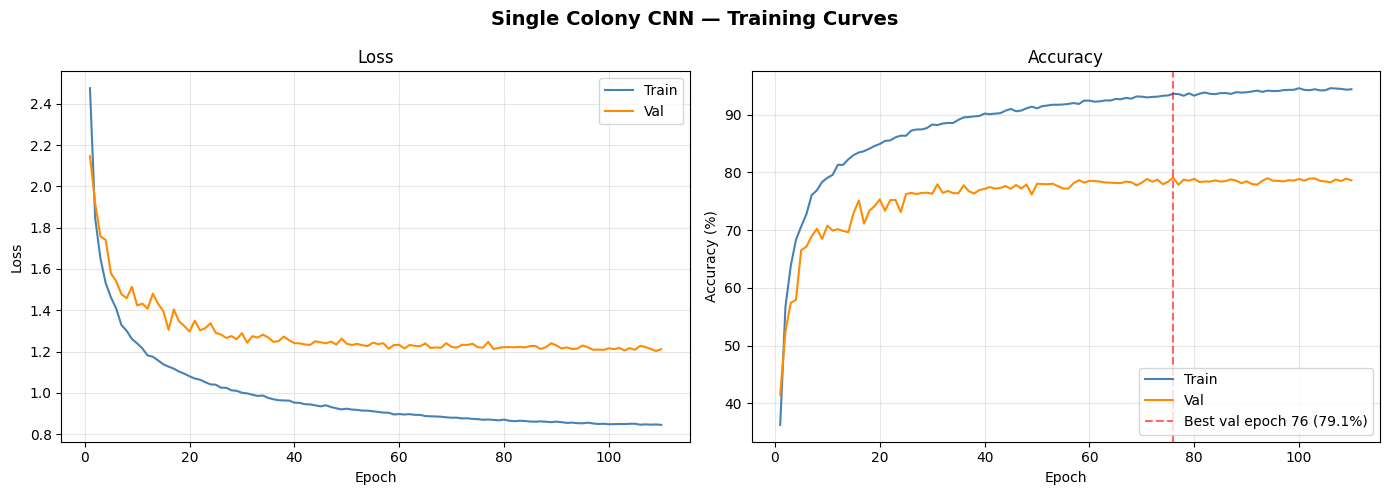

In [ ]:
# ==================== PLOT TRAINING CURVES ====================
def plot_training_curves(history, title='Single Colony CNN', save_dir=None):
    """Plot loss and accuracy curves from history dict.
    Can be called with history loaded from disk — no retraining needed.
    """
    epochs = range(1, len(history['train_losses']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history['train_losses'], label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_losses'],   label='Val',   color='darkorange')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_accs'], label='Train', color='steelblue')
    axes[1].plot(epochs, history['val_accs'],   label='Val',   color='darkorange')
    best_epoch = int(np.argmax(history['val_accs'])) + 1
    best_acc   = max(history['val_accs'])
    axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.6,
                    label=f'Best val epoch {best_epoch} ({best_acc:.1f}%)')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, 'single_cnn_curves.png')
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


# Load history from disk (works after any disconnection)
history_path = os.path.join(OUTPUT_DIR, 'single_cnn_history.pkl')
if os.path.exists(history_path):
    with open(history_path, 'rb') as f:
        _h = pickle.load(f)
    plot_training_curves(_h, title='Single Colony CNN — Training Curves',
                         save_dir=OUTPUT_DIR)
else:
    print('History file not found — run training first.')

### Confusion Matrix — Single Colony CNN

Loads the best saved model from Drive and evaluates it on the validation set.
No retraining required.

Evaluating: 100%|██████████| 88/88 [00:06<00:00, 13.21it/s]


Overall val accuracy: 79.26%
Saved: /content/drive/MyDrive/TFG/resultados_entrenamiento/single_cnn_confusion_matrix.png


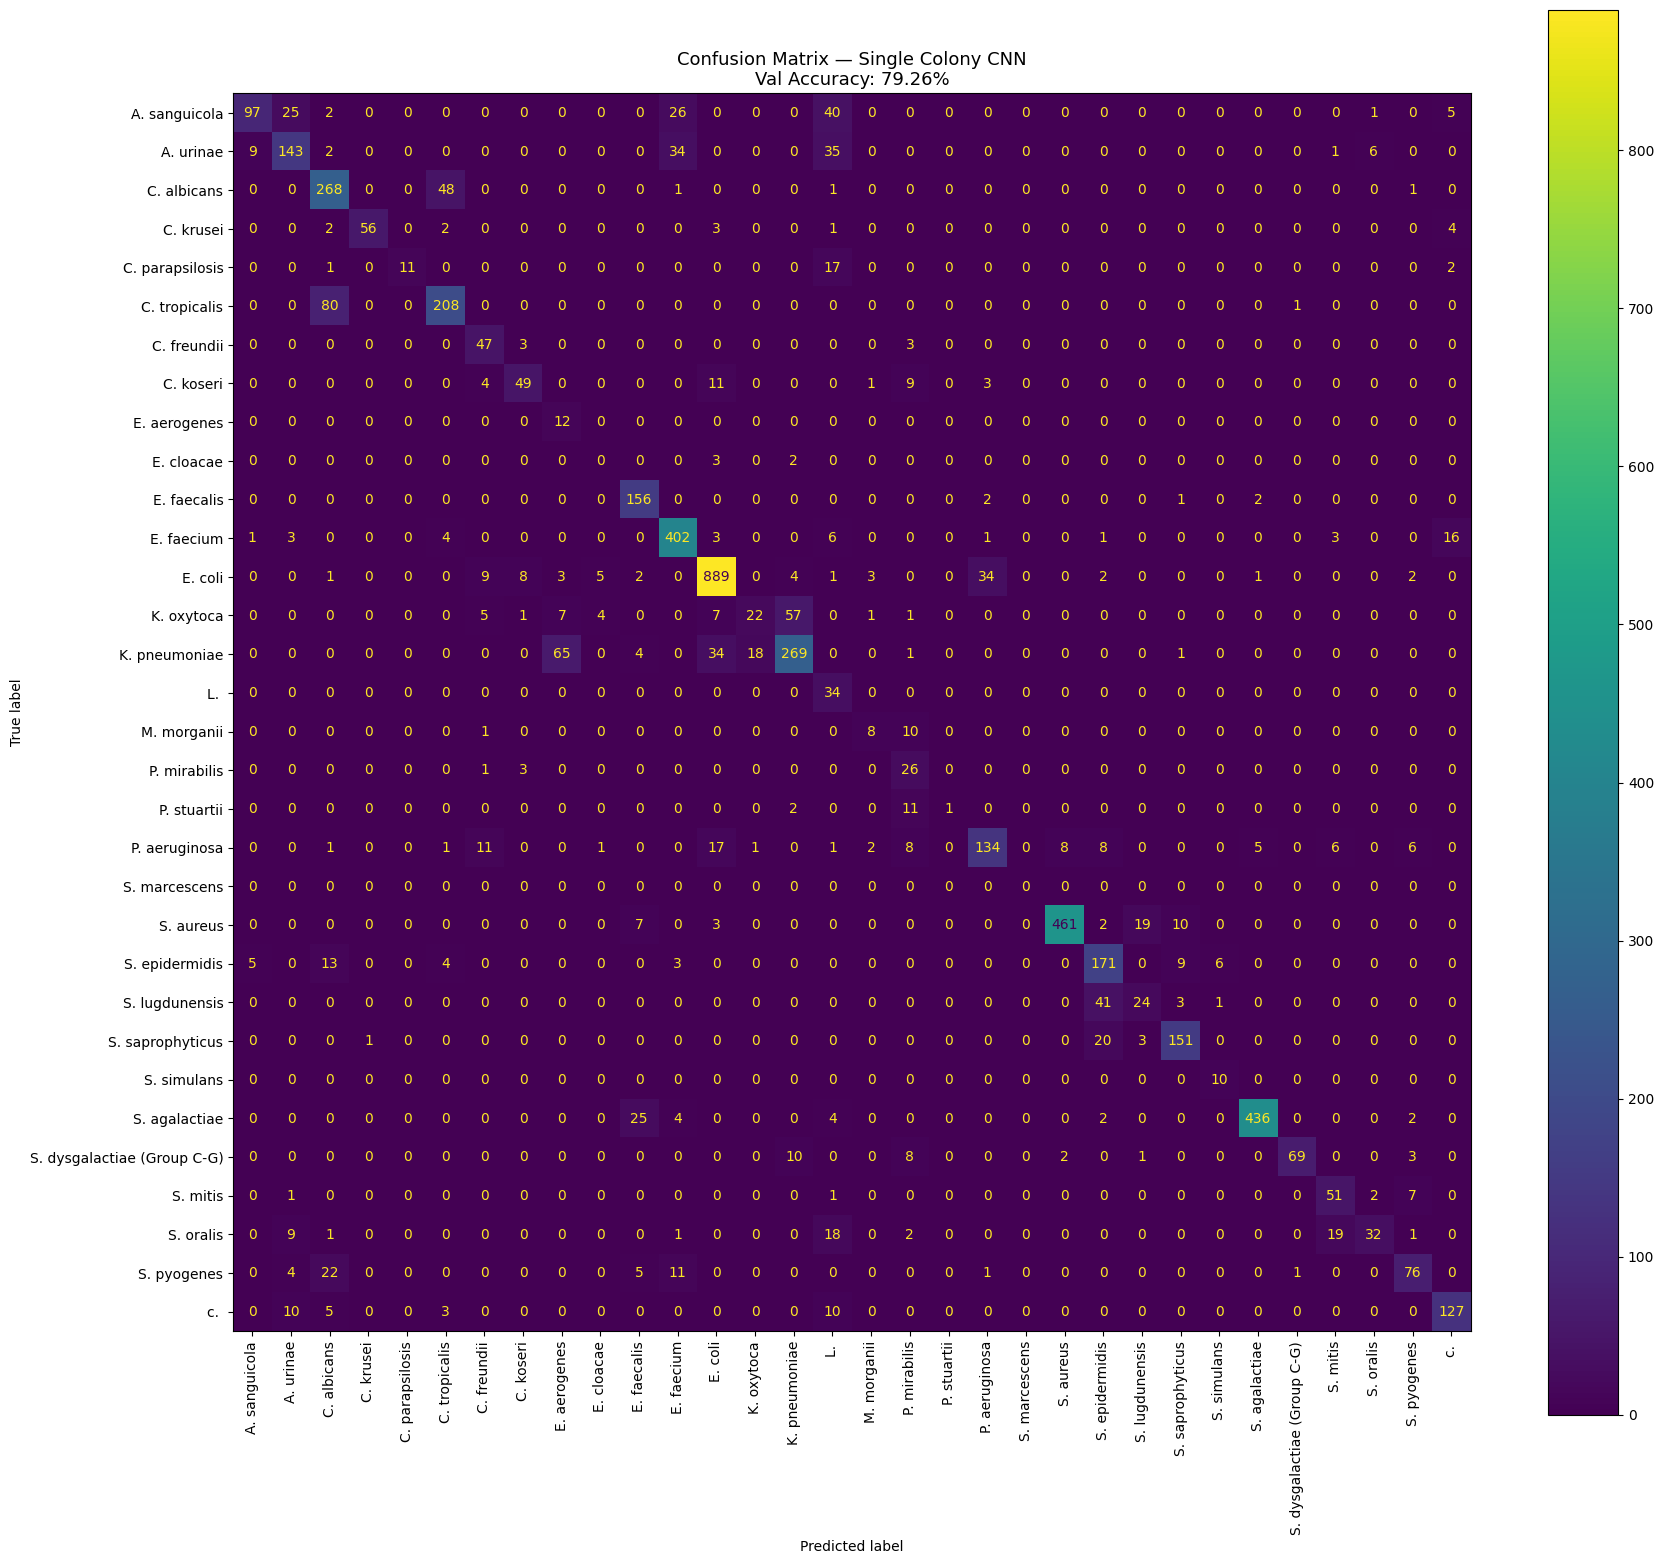

In [ ]:
# ==================== CONFUSION MATRIX (no retraining) ====================
def evaluate_and_plot_confusion(model_path, val_loader, device,
                                 save_dir=None, top_n=None):
    """
    Load best model from disk and compute confusion matrix on val_loader.
    top_n: if set, only display the top_n most frequent classes (cleaner plot).
    """
    ckpt = torch.load(model_path, map_location=device)
    idx_to_species = ckpt['idx_to_species']

    net = SingleColonyCNN().to(device)
    net.load_state_dict(ckpt['model_state_dict'])
    net.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc='Evaluating'):
            imgs   = imgs.to(device)
            preds  = net(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    overall_acc = 100.0 * (all_preds == all_labels).mean()
    print(f'Overall val accuracy: {overall_acc:.2f}%')

    # Short species labels for readability
    n_classes   = len(idx_to_species)
    short_names = []
    for i in range(n_classes):
        parts = idx_to_species[i].split()
        short_names.append(f'{parts[0][0]}. {" ".join(parts[1:])}')

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(n_classes)))

    fig, ax = plt.subplots(figsize=(18, 16))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
    disp.plot(ax=ax, colorbar=True, xticks_rotation=90, values_format='d')
    ax.set_title(f'Confusion Matrix — Single Colony CNN\n'
                 f'Val Accuracy: {overall_acc:.2f}%', fontsize=13)
    plt.tight_layout()

    if save_dir:
        path = os.path.join(save_dir, 'single_cnn_confusion_matrix.png')
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()
    return cm, overall_acc


# ── Confusion matrix on the TEST set ─────────────────────────
# This mirrors the paper: model was selected on val, never saw test during training.
if os.path.exists(MODEL_SAVE_PATH):
    cm, acc = evaluate_and_plot_confusion(
        MODEL_SAVE_PATH, te_loader, DEVICE, save_dir=OUTPUT_DIR   # ← te_loader, not va_loader
    )
else:
    print('Best model not found — run training first.')

---
## Level 3 — Siamese CNN (Architecture + Training)

The Siamese CNN already had checkpoint support. The fix here is in pair generation (Issue 5).

In [ ]:
# ==================== SIAMESE CNN ====================
# KEY ARCHITECTURE NOTES FROM PAPER:
#   - MaxPool stride=1 (not 2) → feature maps stay large intentionally
#     ('the size of the convolutional feature maps before FC are quite large')
#   - PReLU on top of EVERY layer including the output layer
#   - embedding_dim=15 as stated in the Methods section

class SiameseCNN(nn.Module):
    def __init__(self, embedding_dim=15):
        super(SiameseCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 20, kernel_size=5)   # 128→124
        self.conv2 = nn.Conv2d(20, 50, kernel_size=5)  # 123→119

        # PReLU on every layer (including output)
        self.prelu_c1  = nn.PReLU()
        self.prelu_c2  = nn.PReLU()
        self.prelu_fc1 = nn.PReLU()
        self.prelu_fc2 = nn.PReLU()

        # stride=1 intentionally keeps feature maps large
        # (too much distortion invariance is detrimental for similarity)
        # 128 → conv1 → 124 → pool(k=2,s=1) → 123 → conv2 → 119
        # flatten: 50 * 119 * 119 = 708,050
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=1)
        self.fc1     = nn.Linear(50 * 119 * 119, 500)
        self.fc2     = nn.Linear(500, embedding_dim)
        self.dropout = nn.Dropout(0.5)

    def forward_one(self, x):
        x = self.pool(self.prelu_c1(self.conv1(x)))    # [B, 20, 123, 123]
        x = self.prelu_c2(self.conv2(x))               # [B, 50, 119, 119]
        x = x.view(x.size(0), -1)                      # [B, 708050]
        x = self.dropout(self.prelu_fc1(self.fc1(x)))  # [B, 500]
        x = self.prelu_fc2(self.fc2(x))                # [B, 15]
        return x

    def forward(self, x1, x2):
        return self.forward_one(x1), self.forward_one(x2)


# ==================== CONTRASTIVE LOSS ====================
# Eq. 1 from Supp. Note 2:
# E = (1/2N) Σ [ y*||x-xp||² + (1-y)*max(1-||x-xp||², 0)² ]
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        # Euclidean distance (not squared)
        d   = torch.sqrt(torch.sum((out1 - out2) ** 2, dim=1) + 1e-8)

        # Chopra et al. original formula:
        # positive pairs: penalise large d
        # negative pairs: penalise d < margin
        pos = label * d ** 2
        neg = (1 - label) * torch.clamp(self.margin - d, min=0.0) ** 2
        return torch.mean(pos + neg) / 2.0

### Pair Generation & Dataset

In [ ]:
# ==================== SIAMESE DATASET ====================
class SiameseDataset(Dataset):
    def __init__(self, pairs, labels, root_dir, transform=None):
        self.pairs     = pairs
        self.labels    = labels
        self.root_dir  = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        f1, f2 = self.pairs[idx]
        label  = self.labels[idx]
        img1   = Image.open(os.path.join(self.root_dir, f1)).convert('RGB')
        img2   = Image.open(os.path.join(self.root_dir, f2)).convert('RGB')
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        return img1, img2, torch.tensor(label, dtype=torch.float32)


# ==================== PAIR GENERATION ====================
# OLD problem: random.sample(sp_names, 2) gave every species equal probability.
# E. coli (4240 colonies) and Serratia marcescens (41 colonies) were treated
# identically, causing rare species to be underrepresented in impostor pairs.
#
# FIX: random.choices(..., weights=sp_counts) weights each species by its
# colony count, so the impostor distribution mirrors the real data distribution.
def generate_pairs_from_json(json_path, max_pairs_per_plate=50,
                              restrict_to_plates=None):
    """
    Pair generation rules (paper):
      - Genuine  (label=1): same plate AND same strain
      - Impostor (label=0): different species, weighted by colony count
      - Same-strain/different-plate: EXCLUDED from genuine pairs
      - 50/50 balance enforced

    Args:
        restrict_to_plates : optional set of plate_n strings to restrict sampling
                             (used to generate train/val pairs from pre-split plates)
    """
    print(f'Generating pairs (max {max_pairs_per_plate} genuine per plate)...')
    with open(json_path, 'r') as f:
        data = json.load(f)
    samples = list(data['patch_list'].values())

    # Optionally restrict to a plate subset
    if restrict_to_plates is not None:
        samples = [s for s in samples if s['plate_n'] in restrict_to_plates]
        print(f'  Restricted to {len(restrict_to_plates)} plates → {len(samples)} colonies')

    plates         = defaultdict(list)
    species_groups = defaultdict(list)
    for s in samples:
        plates[s['plate_n']].append(s)
        species_groups[s['species']].append(s)

    # ── Genuine pairs: same plate AND same species ────────────────────
    genuine_pairs = []
    for p_name, p_samples in plates.items():
        possible = [
            (p1['filename'], p2['filename'])
            for p1, p2 in itertools.combinations(p_samples, 2)
            if p1['species'] == p2['species']
        ]
        if len(possible) > max_pairs_per_plate:
            possible = random.sample(possible, max_pairs_per_plate)
        genuine_pairs.extend(possible)
    print(f'  Genuine pairs  : {len(genuine_pairs)}')

    # ── Impostor pairs: different species, weighted by colony count ───
    # FIX: weight by species size so rare species appear proportionally
    sp_names  = list(species_groups.keys())
    sp_counts = [len(species_groups[sp]) for sp in sp_names]

    impostor_pairs = []
    target = len(genuine_pairs)
    while len(impostor_pairs) < target:
        # random.choices allows weighted sampling (with replacement)
        sp1, sp2 = random.choices(sp_names, weights=sp_counts, k=2)
        if sp1 == sp2:        # reject same-species draws
            continue
        img1 = random.choice(species_groups[sp1])['filename']
        img2 = random.choice(species_groups[sp2])['filename']
        impostor_pairs.append((img1, img2))

    print(f'  Impostor pairs : {len(impostor_pairs)}')

    # ── Combine and shuffle ───────────────────────────────────────────
    all_pairs  = genuine_pairs + impostor_pairs
    all_labels = [1.0] * len(genuine_pairs) + [0.0] * len(impostor_pairs)
    combined   = list(zip(all_pairs, all_labels))
    random.shuffle(combined)
    pairs, labels = zip(*combined)
    print(f'  Total          : {len(pairs)} pairs  (50/50 balance)')
    return list(pairs), list(labels)

### Siamese Training Loop

In [ ]:
# ==================== TRAIN SIAMESE ====================
# Checkpoint support was already present — no changes to the loop.
# The fix is upstream in generate_pairs_from_json (weighted impostor sampling).
def train_siamese_network(model, train_loader, val_loader, num_epochs,
                           device, save_path, checkpoint_path):
    # ── DEBUG (remove after fix confirmed) ──
    print(f'  [DEBUG] checkpoint_path = {checkpoint_path!r}')
    print(f'  [DEBUG] file exists     = {os.path.exists(checkpoint_path)}')
    # ────────────────────────────────────────

    model     = model.to(device)
    criterion = ContrastiveLoss(margin=1.0)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)
    start_epoch, best_val_loss = 0, float('inf')
    siamese_history = {'train_losses': [], 'val_losses': [],
                       'train_accs':   [], 'val_accs':   []}

    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch     = ckpt['epoch'] + 1
        best_val_loss   = ckpt.get('best_val_loss', float('inf'))
        siamese_history = ckpt.get('history', siamese_history)
        print(f'Resuming from epoch {start_epoch}')
    else:
        print('Starting from scratch.')

    for epoch in range(start_epoch, num_epochs):
        print(f'  [best so far: {best_val_loss:.4f}]')
        # Train
        model.train()
        t_loss, correct, total = 0.0, 0, 0
        for img1, img2, label in tqdm(train_loader,
                                      desc=f'Epoch {epoch+1}/{num_epochs}'):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            optimizer.zero_grad()
            o1, o2 = model(img1, img2)
            loss   = criterion(o1, o2, label)
            loss.backward()
            optimizer.step()
            t_loss  += loss.item()
            d        = torch.sqrt(torch.sum((o1 - o2) ** 2, dim=1) + 1e-8)
            correct += ((d < 0.5).float() == label).sum().item()
            total   += label.size(0)

        # Val
        model.eval()
        v_loss, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for img1, img2, label in val_loader:
                img1, img2, label = img1.to(device), img2.to(device), label.to(device)
                o1, o2 = model(img1, img2)
                loss   = criterion(o1, o2, label)
                v_loss += loss.item()
                d2      = torch.sum((o1 - o2) ** 2, dim=1)
                vc     += ((d2 < 0.5).float() == label).sum().item()
                vt     += label.size(0)

        avg_tl = t_loss / len(train_loader)
        avg_vl = v_loss / len(val_loader)
        t_acc  = 100.0 * correct / total
        v_acc  = 100.0 * vc / vt

        siamese_history['train_losses'].append(avg_tl)
        siamese_history['val_losses'].append(avg_vl)
        siamese_history['train_accs'].append(t_acc)
        siamese_history['val_accs'].append(v_acc)

        print(f'Epoch {epoch+1}: '
              f'Train Loss={avg_tl:.4f} Acc={t_acc:.1f}% | '
              f'Val Loss={avg_vl:.4f} Acc={v_acc:.1f}%')

        if avg_vl < best_val_loss:
            best_val_loss = avg_vl
            torch.save(model.state_dict(), save_path)
            print(f'  → Best model saved (Val Loss: {avg_vl:.4f})')
        # Checkpoint every epoch
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss'       : best_val_loss,
            'history'             : siamese_history,
        }, checkpoint_path)

    return siamese_history

### Main — Train Siamese CNN

In [ ]:
# ==================== RESTORE PLATE SPLIT (if lost after disconnection) ====================
# TRAIN_PLATES / VAL_PLATES / TEST_PLATES are defined in the Single Colony CNN main cell.
# If that cell hasn't been run yet this session, recompute the split here.
# Uses the same seed → identical plate assignments every time.

import os, json
from collections import defaultdict

if 'TRAIN_PLATES' not in dir() or 'VAL_PLATES' not in dir() or 'TEST_PLATES' not in dir():
    print('Plate split variables not found — recomputing from metadata...')

    METADATA_PATH = os.path.join(WORK_DIR, 'metadata.json')
    DATASET_PATH  = os.path.join(WORK_DIR, 'Dataset')

    full_ds = ColonyDataset(METADATA_PATH, DATASET_PATH, transform=None)

    tr_idx, va_idx, te_idx, TRAIN_PLATES, VAL_PLATES, TEST_PLATES = make_plate_aware_split(
        full_ds, val_ratio=0.2, test_ratio=0.2, seed=GLOBAL_SEED
    )
    print('Split restored.')
else:
    print('Plate split already in memory — skipping recompute.')

print(f'  TRAIN_PLATES : {len(TRAIN_PLATES)}')
print(f'  VAL_PLATES   : {len(VAL_PLATES)}')
print(f'  TEST_PLATES  : {len(TEST_PLATES)}')

Plate split already in memory — skipping recompute.
  TRAIN_PLATES : 811
  VAL_PLATES   : 270
  TEST_PLATES  : 270


In [ ]:
# ── Free GPU memory from Single Colony CNN ──────────────────
import gc
if 'model' in dir() and hasattr(model, 'parameters'):
    model.cpu()          # move weights off GPU
    del model            # remove reference
if 'single_cnn' in dir():
    single_cnn.cpu()
    del single_cnn
gc.collect()
torch.cuda.empty_cache()
print(f'GPU free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB')
# ────────────────────────────────────────────────────────────

GPU free: 15.53 GB


In [ ]:
# ==================== MAIN — SIAMESE CNN ====================
# Uses TRAIN_PLATES / VAL_PLATES from the plate-aware split above
# so the Siamese sees the same plate division as the SingleColonyCNN.
torch.cuda.empty_cache()

METADATA_PATH    = os.path.join(WORK_DIR,   'metadata.json')
DATASET_PATH     = os.path.join(WORK_DIR,   'Dataset')
SIAMESE_SAVE_PATH   = os.path.join(OUTPUT_DIR, 'best_siamese_model.pth')
SIAMESE_CKPT_PATH   = os.path.join(OUTPUT_DIR, 'siamese_checkpoint_resume.pth')

SIAMESE_BATCH_SIZE  = 64
SIAMESE_NUM_EPOCHS  = 50
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

# Generate pairs restricted to train plates for training,
# and val plates for validation — consistent with the CNN split.
print('=== Generating TRAIN pairs ===')
tr_pairs, tr_labels = generate_pairs_from_json(
    METADATA_PATH, max_pairs_per_plate=50,
    restrict_to_plates=TRAIN_PLATES
)
print('\n=== Generating VAL pairs ===')
va_pairs, va_labels = generate_pairs_from_json(
    METADATA_PATH, max_pairs_per_plate=50,
    restrict_to_plates=VAL_PLATES
)

transform = transforms.Compose([
    AdaptivePadding(20),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])
tr_siam_ds = SiameseDataset(tr_pairs, tr_labels, DATASET_PATH, transform)
va_siam_ds = SiameseDataset(va_pairs, va_labels, DATASET_PATH, transform)
tr_siam_loader = DataLoader(tr_siam_ds, SIAMESE_BATCH_SIZE,
                             shuffle=True,  num_workers=2)
va_siam_loader = DataLoader(va_siam_ds, SIAMESE_BATCH_SIZE,
                             shuffle=False, num_workers=2)

siamese_model = SiameseCNN(embedding_dim=15)
if not os.path.exists(SIAMESE_CKPT_PATH):
    siamese_model.apply(init_weights)

siamese_history = train_siamese_network(
    siamese_model, tr_siam_loader, va_siam_loader,
    SIAMESE_NUM_EPOCHS, DEVICE,
    SIAMESE_SAVE_PATH, SIAMESE_CKPT_PATH
)

with open(os.path.join(OUTPUT_DIR, 'siamese_history.pkl'), 'wb') as f:
    pickle.dump(siamese_history, f)
print('Siamese training complete.')

=== Generating TRAIN pairs ===
Generating pairs (max 50 genuine per plate)...
  Restricted to 811 plates → 15747 colonies
  Genuine pairs  : 23084
  Impostor pairs : 23084
  Total          : 46168 pairs  (50/50 balance)

=== Generating VAL pairs ===
Generating pairs (max 50 genuine per plate)...
  Restricted to 270 plates → 4864 colonies
  Genuine pairs  : 7452
  Impostor pairs : 7452
  Total          : 14904 pairs  (50/50 balance)
  [DEBUG] checkpoint_path = '/content/drive/MyDrive/TFG/resultados_entrenamiento/siamese_checkpoint_resume.pth'
  [DEBUG] file exists     = True
Resuming from epoch 50
Siamese training complete.


### Training Curves — Siamese CNN

Saved: /content/drive/MyDrive/TFG/resultados_entrenamiento/single_cnn_curves.png


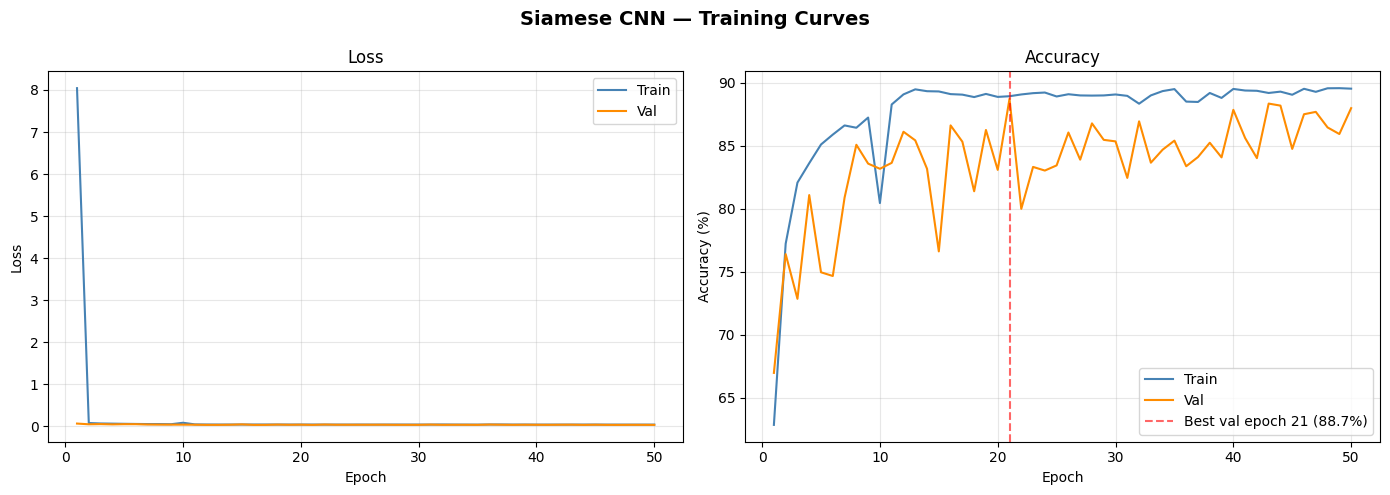

In [ ]:
# Load and plot Siamese history (no retraining needed)
siam_history_path = os.path.join(OUTPUT_DIR, 'siamese_history.pkl')
if os.path.exists(siam_history_path):
    with open(siam_history_path, 'rb') as f:
        _sh = pickle.load(f)
    plot_training_curves(_sh, title='Siamese CNN — Training Curves',
                         save_dir=OUTPUT_DIR)
else:
    print('Siamese history not found — run training first.')

In [ ]:
ckpt = torch.load(SIAMESE_CKPT_PATH, map_location='cpu')
losses = ckpt['history']['train_losses']
print([round(l, 6) for l in losses])

[4.390032, 0.108547, 0.095785, 0.088256, 0.081357, 0.077615, 0.076419, 0.073556, 0.07102, 0.067494, 0.063736, 0.063467, 0.062009, 0.062749, 0.062349, 0.061449, 0.06208, 0.060666, 0.059647, 0.059862, 0.062117, 0.060238, 0.059462, 0.060303, 0.06007, 0.059377, 0.060287, 0.060551, 0.060085, 0.060245, 0.060872, 0.059647, 0.059609, 0.059112, 0.058934, 0.058531, 0.058402, 0.058454, 0.058475, 0.058381, 0.058725, 0.058478, 0.057853, 0.058525, 0.057272, 0.057788, 0.059425, 0.058609, 0.057869, 0.058064]


---
## Level 3 — Inference: Embedding + Clustering + Smoothing

In [ ]:
# ==================== LEVEL 3 — EMBEDDING + CLUSTERING + SMOOTHING ====================
# Step 1 – Embed : one S-CNN branch → 15-dim vector per good colony
# Step 2 – Cluster: Mean-Shift on embedding space → strain groups
# Step 3 – Smooth : average pIDv's within each cluster → consensus ID

TRANSFORM_INFERENCE = transforms.Compose([
    AdaptivePadding(margin=20),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])


def get_pIDv_batch(image_paths, single_cnn, device, batch_size=32):
    """Run SingleColonyCNN on a list of paths → [M, 32] softmax outputs."""
    single_cnn.eval()
    all_pIDv = []
    for i in range(0, len(image_paths), batch_size):
        batch = image_paths[i:i + batch_size]
        imgs  = torch.stack([
            TRANSFORM_INFERENCE(Image.open(p).convert('RGB')) for p in batch
        ]).to(device)
        with torch.no_grad():
            pIDv = torch.softmax(single_cnn(imgs), dim=1).cpu().numpy()
        all_pIDv.append(pIDv)
    return np.vstack(all_pIDv)  # [M, 32]


def get_embeddings_batch(image_paths, siamese_cnn, device, batch_size=32):
    """Run one S-CNN branch → [M, 15] embedding matrix."""
    siamese_cnn.eval()
    all_emb = []
    for i in range(0, len(image_paths), batch_size):
        batch = image_paths[i:i + batch_size]
        imgs  = torch.stack([
            TRANSFORM_INFERENCE(Image.open(p).convert('RGB')) for p in batch
        ]).to(device)
        with torch.no_grad():
            emb = siamese_cnn.forward_one(imgs).cpu().numpy()
        all_emb.append(emb)
    return np.vstack(all_emb)  # [M, 15]


def cluster_with_meanshift(embeddings, bandwidth=None, quantile=0.3):
    """Mean-Shift clustering on colony embeddings → cluster label per colony."""
    if len(embeddings) == 1:
        return np.array([0])
    if bandwidth is None:
        bandwidth = estimate_bandwidth(
            embeddings, quantile=quantile,
            n_samples=min(len(embeddings), 500)
        )
        bandwidth = max(bandwidth, 1e-3)

    # Try with bin_seeding first (faster), fall back if it fails
    for bin_seeding in (True, False):
        try:
            ms = MeanShift(bandwidth=bandwidth, bin_seeding=bin_seeding, cluster_all=True)
            ms.fit(embeddings)
            break
        except ValueError:
            if not bin_seeding:
                # Both failed — assign everything to one cluster
                print(f'    Mean-Shift: failed at bw={bandwidth:.4f}, returning 1 cluster')
                return np.zeros(len(embeddings), dtype=int)

    n = len(np.unique(ms.labels_))
    print(f'    Mean-Shift: {len(embeddings)} colonies → {n} cluster(s) '
          f'(bw={bandwidth:.4f})')
    return ms.labels_


def smooth_pIDv(pIDv_matrix, cluster_labels):
    """Average pIDv within each cluster → consensus sIDv per colony."""
    sIDv = np.zeros_like(pIDv_matrix)
    for cid in np.unique(cluster_labels):
        mask       = (cluster_labels == cid)
        mean_pIDv  = pIDv_matrix[mask].mean(axis=0)
        mean_pIDv /= mean_pIDv.sum() + 1e-9
        sIDv[mask] = mean_pIDv
        top1       = np.argmax(mean_pIDv)
        print(f'    Cluster {cid}: {mask.sum()} colonies | '
              f'top-1 idx={top1} (conf={mean_pIDv[top1]:.3f})')
    return sIDv


def run_level3(image_paths, pIDv_matrix, siamese_cnn, device,
               bandwidth=None, quantile=0.3):
    """Full Level 3 pipeline for one plate."""
    print(f'  Level 3 | {len(image_paths)} good colonies')
    print('  [1/3] Generating 15-dim embeddings...')
    embeddings = get_embeddings_batch(image_paths, siamese_cnn, device)

    print('  [2/3] Mean-Shift clustering...')
    cluster_labels = cluster_with_meanshift(embeddings, bandwidth, quantile)

    print('  [3/3] Smoothing pIDv within clusters...')
    sIDv_matrix = smooth_pIDv(pIDv_matrix, cluster_labels)

    n_clusters = len(np.unique(cluster_labels))
    changed    = int((np.argmax(pIDv_matrix, 1) != np.argmax(sIDv_matrix, 1)).sum())
    print(f'  Done: {n_clusters} group(s), {changed}/{len(image_paths)} IDs updated')
    return sIDv_matrix, cluster_labels, embeddings

---
## Level 3 — Evaluation & Visualization

Device: cuda

[A] Loading models ...
  SingleColonyCNN loaded  (32 classes)
SiameseCNN loaded  (15-dim embedding)

[B] Building test-plate index from metadata ...
  Test plates  : 270
  Test colonies: 5602

[C] Running Level 2 → Level 3 on all test plates ...


Plates:   1%|          | 2/270 [00:01<02:45,  1.62it/s]

    Mean-Shift: 10 colonies → 1 cluster(s) (bw=0.1084)
    Cluster 0: 10 colonies | top-1 idx=25 (conf=0.567)
    Mean-Shift: 7 colonies → 5 cluster(s) (bw=0.0836)
    Cluster 0: 3 colonies | top-1 idx=17 (conf=0.406)
    Cluster 1: 1 colonies | top-1 idx=17 (conf=0.240)
    Cluster 2: 1 colonies | top-1 idx=17 (conf=0.403)
    Cluster 3: 1 colonies | top-1 idx=18 (conf=0.260)
    Cluster 4: 1 colonies | top-1 idx=17 (conf=0.479)
    Mean-Shift: 7 colonies → 1 cluster(s) (bw=0.0342)
    Cluster 0: 7 colonies | top-1 idx=17 (conf=0.578)


Plates:   1%|▏         | 4/270 [00:02<02:25,  1.83it/s]

    Mean-Shift: 142 colonies → 1 cluster(s) (bw=0.1827)
    Cluster 0: 142 colonies | top-1 idx=26 (conf=0.792)


...

    Mean-Shift: 4 colonies → 4 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.483)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.314)
    Cluster 2: 1 colonies | top-1 idx=12 (conf=0.716)
    Cluster 3: 1 colonies | top-1 idx=12 (conf=0.538)
    Mean-Shift: 7 colonies → 5 cluster(s) (bw=0.0660)
    Cluster 0: 2 colonies | top-1 idx=12 (conf=0.890)
    Cluster 1: 2 colonies | top-1 idx=12 (conf=0.630)
    Cluster 2: 1 colonies | top-1 idx=12 (conf=0.751)
    Cluster 3: 1 colonies | top-1 idx=12 (conf=0.843)
    Cluster 4: 1 colonies | top-1 idx=12 (conf=0.912)
    Mean-Shift: 2 colonies → 2 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.857)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.875)
    Mean-Shift: 5 colonies → 5 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.859)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.867)
    Cluster 2: 1 colonies | top-1 idx=12 (conf=0.763)
    Cluster 3: 1 colonies | 

Top-k pass:  98%|█████████▊| 265/270 [00:31<00:00, 21.36it/s]

    Mean-Shift: 3 colonies → 3 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.836)
    Cluster 1: 1 colonies | top-1 idx=6 (conf=0.487)
    Cluster 2: 1 colonies | top-1 idx=12 (conf=0.466)
    Mean-Shift: 6 colonies → 6 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.889)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.899)
    Cluster 2: 1 colonies | top-1 idx=12 (conf=0.923)
    Cluster 3: 1 colonies | top-1 idx=12 (conf=0.921)
    Cluster 4: 1 colonies | top-1 idx=12 (conf=0.864)
    Cluster 5: 1 colonies | top-1 idx=12 (conf=0.833)
    Mean-Shift: 3 colonies → 3 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.719)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.713)
    Cluster 2: 1 colonies | top-1 idx=12 (conf=0.842)
    Mean-Shift: 2 colonies → 2 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.802)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.704)
    Mean-Shift: 2 colonies → 

Top-k pass: 100%|██████████| 270/270 [00:31<00:00,  8.62it/s]


    Mean-Shift: 3 colonies → 3 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.907)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.935)
    Cluster 2: 1 colonies | top-1 idx=12 (conf=0.935)
    Mean-Shift: 2 colonies → 2 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.871)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.904)
    Mean-Shift: 2 colonies → 2 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.801)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.875)
    Mean-Shift: 2 colonies → 2 cluster(s) (bw=0.0010)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.907)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.842)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.885)

  ┌──────────────────────────────────┐
  │   Accuracy comparison  (test set) │
  ├────────────┬──────────┬───────────┤
  │            │  L2 (%)  │  L3 (%)   │
  ├────────────┼──────────┼───────────┤
  │  Top-1      │   79.26  │   88.34   │  Δ=

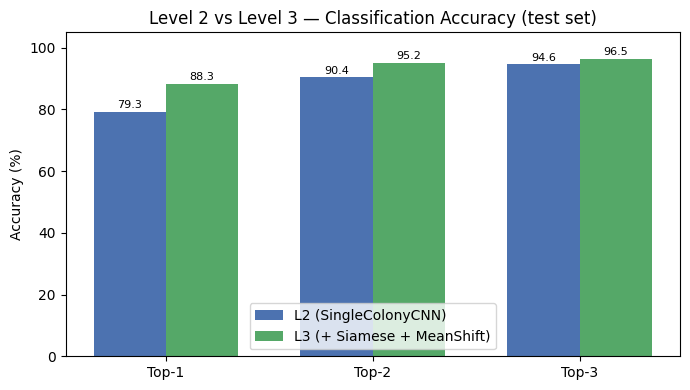

Saved: e1_accuracy_comparison.png


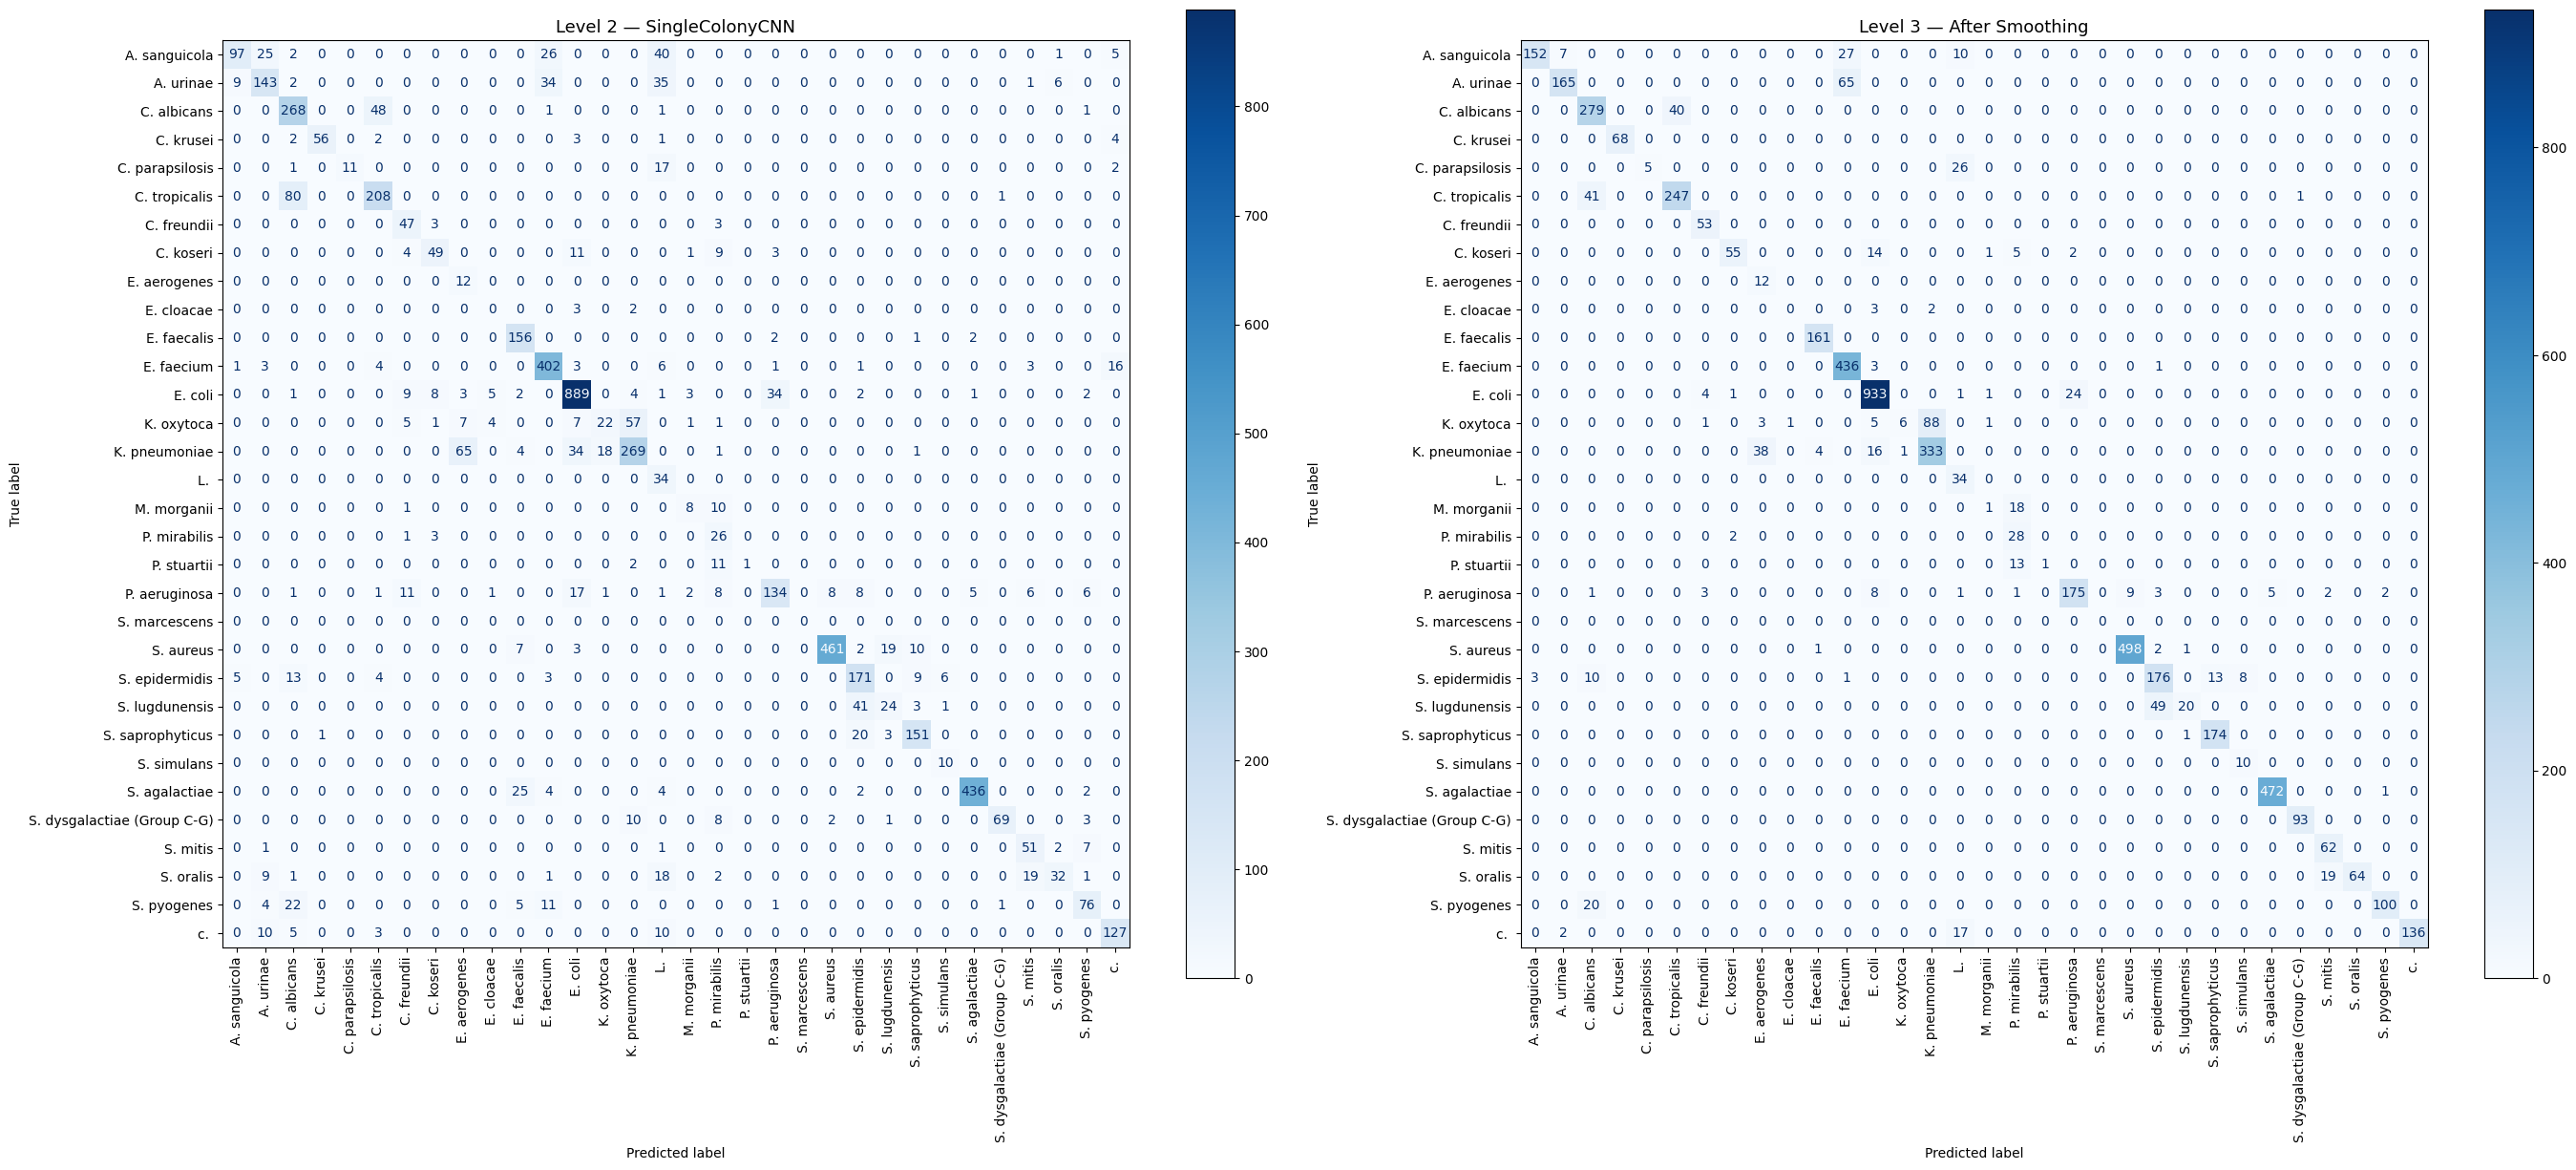

Saved: e2_confusion_matrices.png


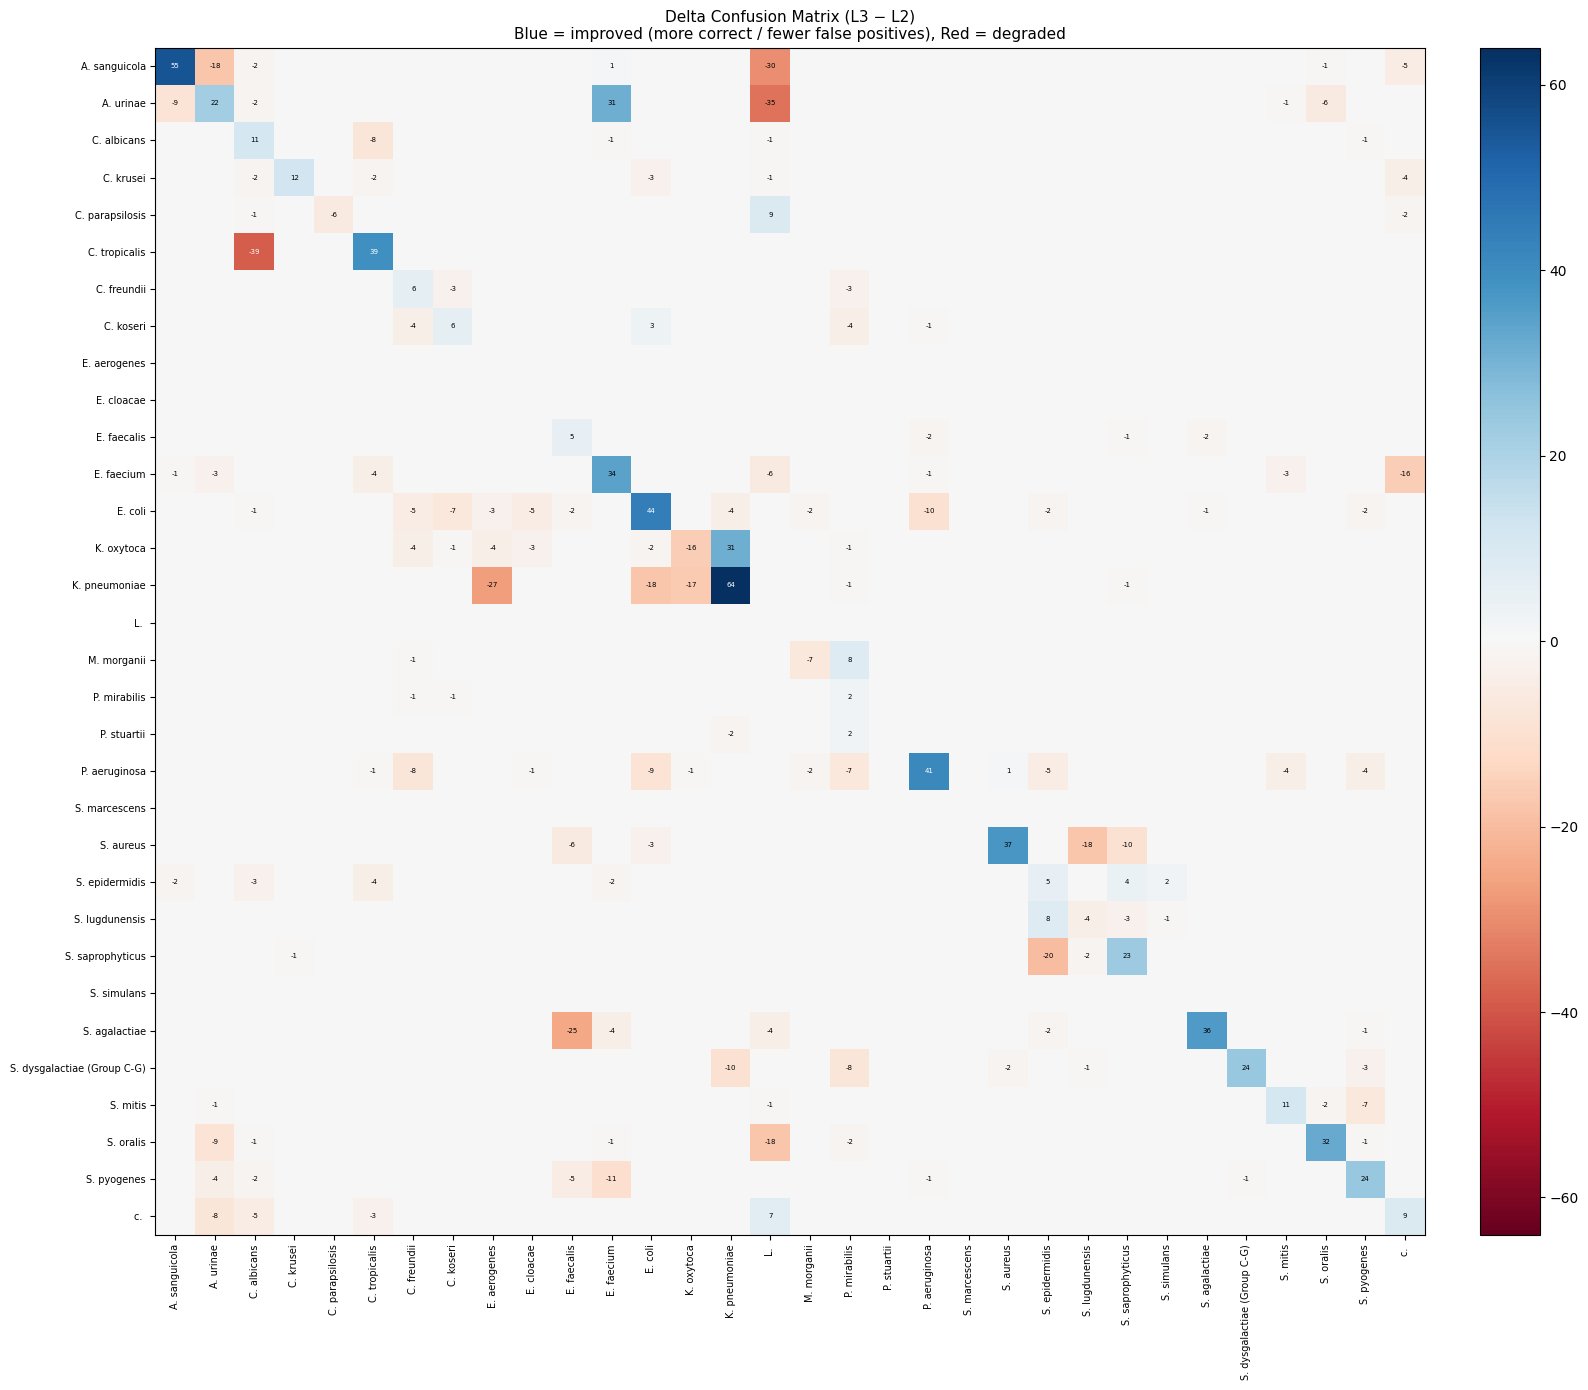

Saved: e3_delta_confusion.png

  PCA on all test embeddings ...


/tmp/ipykernel_3541/4227199537.py:328: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_species = plt.cm.get_cmap('tab20', N_CLASSES)


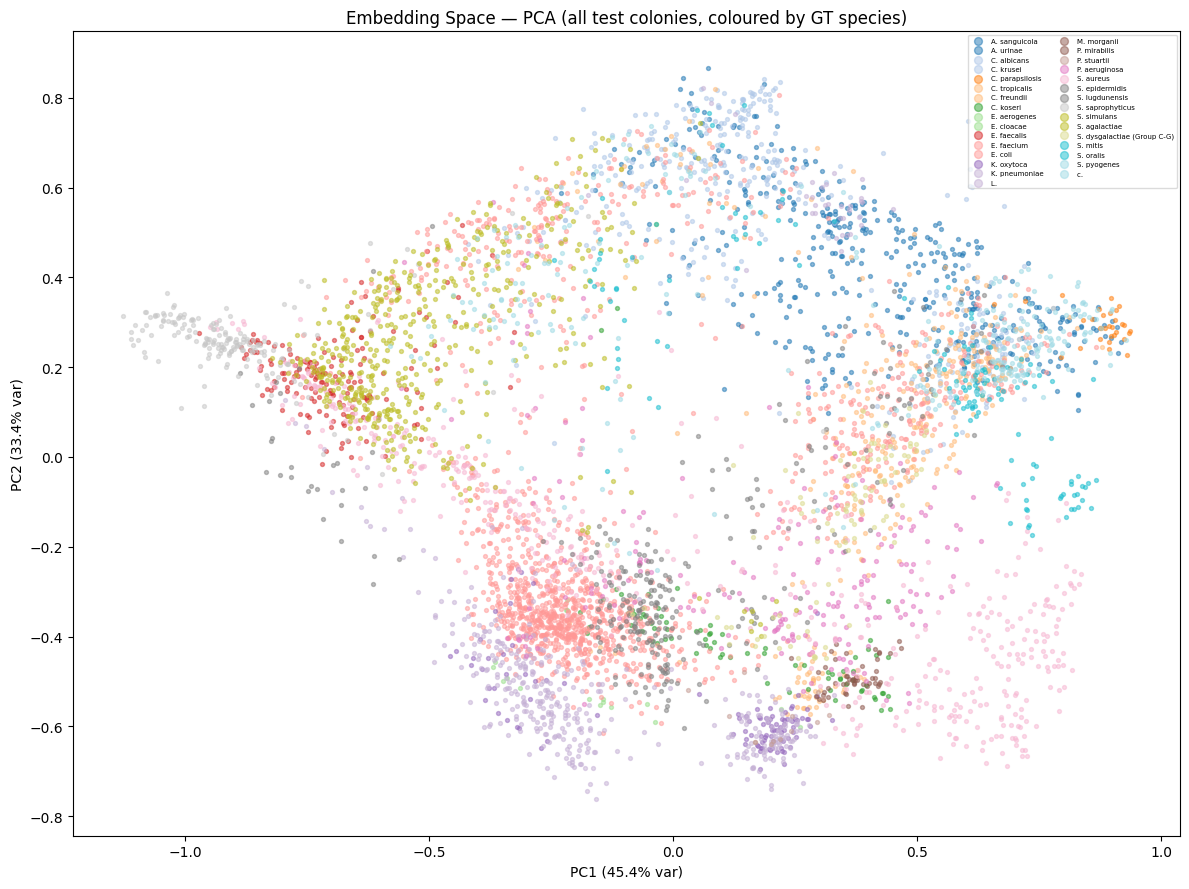

Saved: e4_pca_gt_species.png
  No multi-species plates — using largest single-species plate: plate_n_24_Streptococcus agalactiae
  (142 colonies)
    Mean-Shift: 142 colonies → 1 cluster(s) (bw=0.1827)
    Cluster 0: 142 colonies | top-1 idx=26 (conf=0.792)


/tmp/ipykernel_3541/4227199537.py:377: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_gt   = plt.cm.get_cmap('tab10', len(unique_gts))
/tmp/ipykernel_3541/4227199537.py:378: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cl   = plt.cm.get_cmap('Set1',  len(unique_clusters))


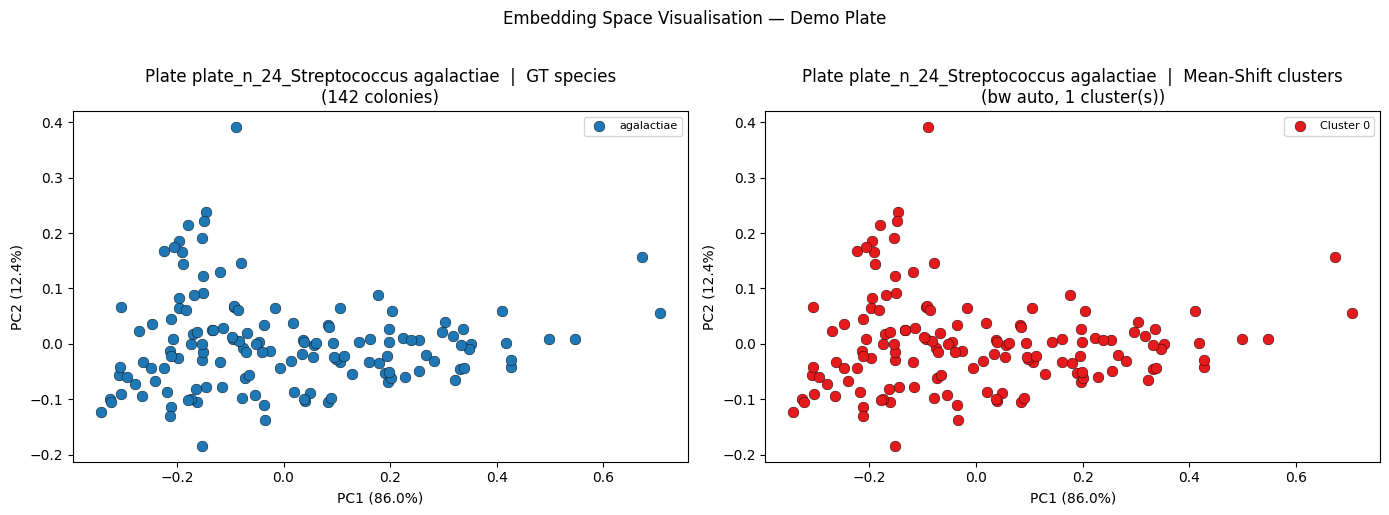

Saved: e5_pca_demo_plate.png


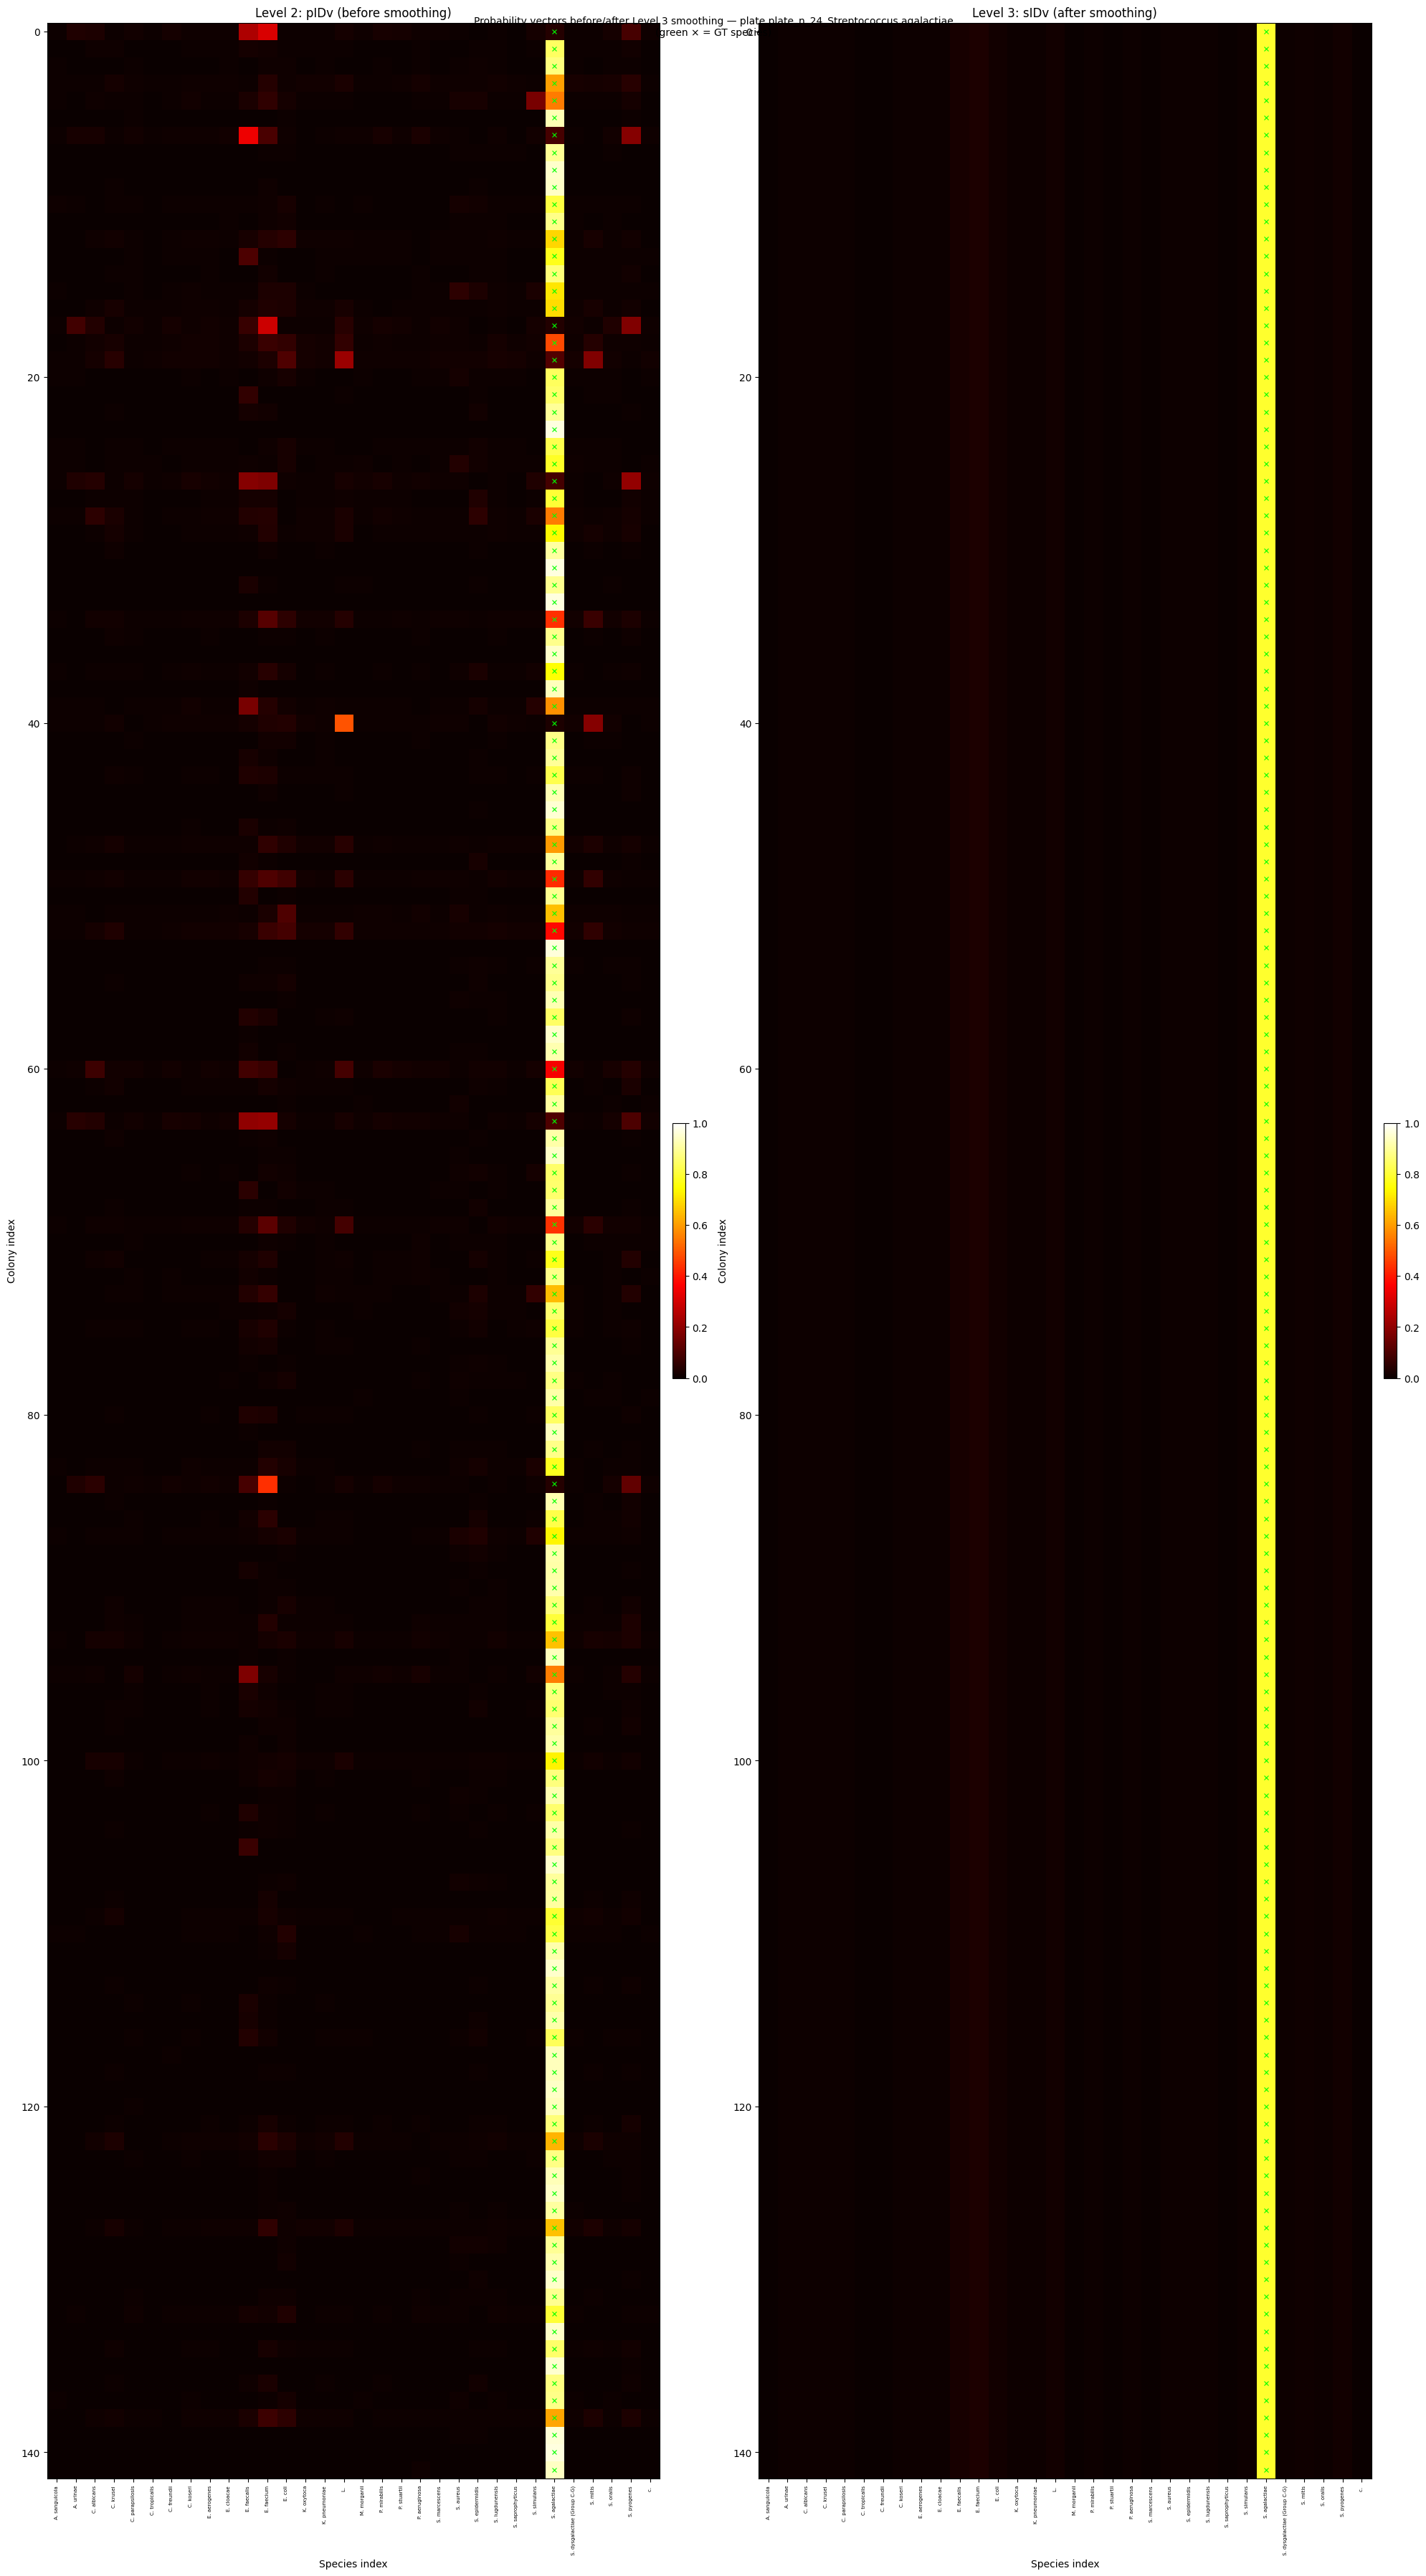

Saved: e6_pIDv_heatmap.png


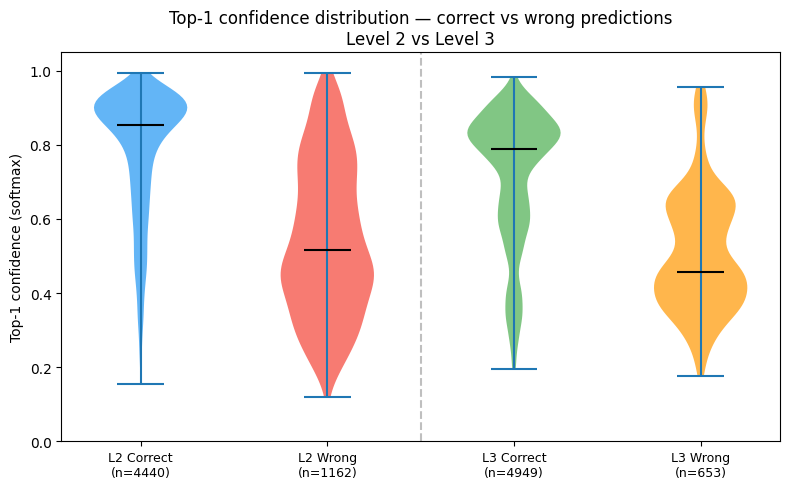

Saved: e7_confidence_violin.png


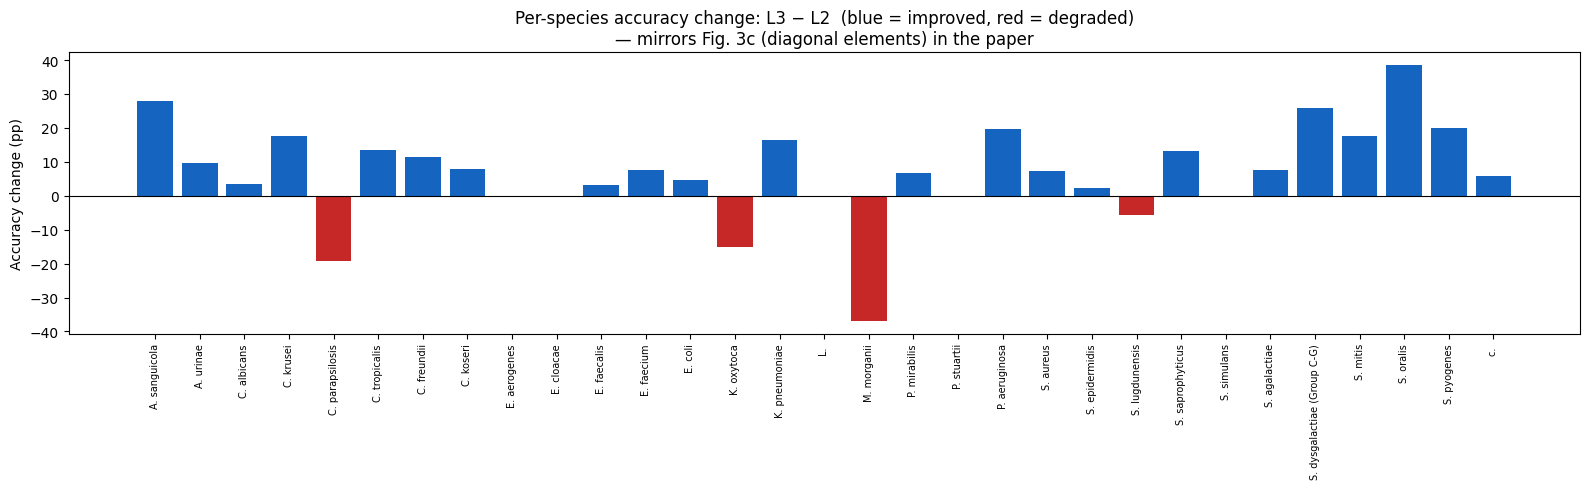

Saved: e9_per_species_delta.png

LEVEL 3 EVALUATION COMPLETE
  Top-1: L2=79.26%  L3=88.34%  Δ=+9.09 pp
  Top-2: L2=90.41%  L3=95.16%  Δ=+4.75 pp
  Top-3: L2=94.59%  L3=96.50%  Δ=+1.91 pp

All plots saved in: /content/drive/MyDrive/TFG/resultados_entrenamiento/level3_eval


In [ ]:
# ==================== LEVEL 3 — EVALUATION & VISUALISATION ====================
# Following the paper closely:
#   A) Load both trained models from Drive (no retraining)
#   B) Group test-set colonies by plate  →  the natural unit for Level 3
#   C) Per plate: run L2 (pIDv) then L3 (embed → cluster → smooth → sIDv)
#   D) Aggregate across all test plates:
#        • Top-1 / Top-2 / Top-3 accuracy  (L2 vs L3, mirrors paper Table / Fig.3)
#        • Confusion matrix (L2), Confusion matrix (L3), Delta matrix  (Fig.3a,c)
#        • Clustering quality: Homogeneity, Completeness, V-measure  (Supp. Note 3)
#   E) Visualisations:
#        • Embedding PCA — all test colonies, coloured by GT species
#        • Embedding PCA — one representative plate, coloured by (a) GT, (b) cluster
#        • pIDv bar-chart  before / after smoothing for one plate
#        • Confidence distribution shift (violin plot L2 vs L3 top-1 confidence)

import os, json, pickle, random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import defaultdict
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    homogeneity_completeness_v_measure
)
from sklearn.decomposition import PCA
import torch
from PIL import Image
from tqdm import tqdm

# ── Paths (same as the rest of the notebook) ──────────────────────────────────
METADATA_PATH       = os.path.join(WORK_DIR,   'metadata.json')
DATASET_PATH        = os.path.join(WORK_DIR,   'Dataset')
MODEL_SAVE_PATH     = os.path.join(OUTPUT_DIR, 'best_single_colony_model.pth')
SIAMESE_SAVE_PATH   = os.path.join(OUTPUT_DIR, 'best_siamese_model.pth')
EVAL_OUTPUT_DIR     = os.path.join(OUTPUT_DIR, 'level3_eval')
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


# ==============================================================================
# A — LOAD BOTH MODELS
# ==============================================================================
print('\n[A] Loading models ...')

# ── SingleColonyCNN ───────────────────────────────────────────────────────────
ckpt_cnn = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
IDX_TO_SPECIES = ckpt_cnn['idx_to_species']          # dict  {int: str}
SPECIES_TO_IDX = {v: k for k, v in IDX_TO_SPECIES.items()}
N_CLASSES      = len(IDX_TO_SPECIES)

single_cnn = SingleColonyCNN().to(DEVICE)
single_cnn.load_state_dict(ckpt_cnn['model_state_dict'])
single_cnn.eval()
print(f'  SingleColonyCNN loaded  ({N_CLASSES} classes)')

# ── SiameseCNN ────────────────────────────────────────────────────────────────
ckpt_siam = torch.load(SIAMESE_SAVE_PATH, map_location=DEVICE)

siamese_cnn = SiameseCNN(embedding_dim=15).to(DEVICE)
siamese_cnn.load_state_dict(ckpt_siam)  # checkpoint IS the state dict
siamese_cnn.eval()
print('SiameseCNN loaded  (15-dim embedding)')


# ==============================================================================
# B — BUILD TEST-PLATE INDEX  (plate → list of {path, gt_idx})
# ==============================================================================
print('\n[B] Building test-plate index from metadata ...')

with open(METADATA_PATH) as f:
    meta = json.load(f)

# Reconstruct TEST_PLATES if not already in memory (same seed → identical split)
if 'TEST_PLATES' not in dir():
    print('  TEST_PLATES not found in memory — recomputing plate split ...')
    full_ds = ColonyDataset(METADATA_PATH, DATASET_PATH, transform=None)
    _, _, _, TRAIN_PLATES, VAL_PLATES, TEST_PLATES = make_plate_aware_split(
        full_ds, val_ratio=0.2, test_ratio=0.2, seed=GLOBAL_SEED
    )
    print('  Done.')

# Group test colonies by plate
plate_to_colonies = defaultdict(list)
for fname, info in meta['patch_list'].items():
    plate_id = info['plate_n']
    if plate_id in TEST_PLATES:
        gt_str = info['species']
        if gt_str in SPECIES_TO_IDX:
            plate_to_colonies[plate_id].append({
                'path'   : os.path.join(DATASET_PATH, info['filename']),
                'gt_idx' : SPECIES_TO_IDX[gt_str],
                'gt_str' : gt_str,
            })

n_test_plates   = len(plate_to_colonies)
n_test_colonies = sum(len(v) for v in plate_to_colonies.values())
print(f'  Test plates  : {n_test_plates}')
print(f'  Test colonies: {n_test_colonies}')


# ==============================================================================
# C — RUN L2 + L3 ON EVERY TEST PLATE  (plate-level context for clustering)
# ==============================================================================
print('\n[C] Running Level 2 → Level 3 on all test plates ...')

all_gt        = []   # GT label index per colony
all_l2_pred   = []   # Top-1 index after L2 (SingleColonyCNN alone)
all_l3_pred   = []   # Top-1 index after L3 smoothing
all_l2_conf   = []   # Top-1 confidence before smoothing
all_l3_conf   = []   # Top-1 confidence after smoothing
all_embeddings = []  # 15-dim embedding per colony
all_clusters  = []   # cluster label per colony (plate-local, offset globally)
all_plate_ids = []   # plate id per colony  (for per-plate metrics)
cluster_hom   = []   # per-plate homogeneity
cluster_comp  = []   # per-plate completeness
cluster_vm    = []   # per-plate v-measure
global_cluster_offset = 0

plate_list = list(plate_to_colonies.items())

for plate_id, colonies in tqdm(plate_list, desc='Plates'):
    paths  = [c['path']   for c in colonies]
    labels = [c['gt_idx'] for c in colonies]
    gts    = [c['gt_str'] for c in colonies]

    if len(paths) == 0:
        continue

    # ── Level 2 ───────────────────────────────────────────────────────────────
    pIDv = get_pIDv_batch(paths, single_cnn, DEVICE)   # [M, 32]

    # ── Level 3 ───────────────────────────────────────────────────────────────
    embs          = get_embeddings_batch(paths, siamese_cnn, DEVICE)  # [M, 15]
    clust_labels  = cluster_with_meanshift(embs)                       # [M]
    sIDv          = smooth_pIDv(pIDv, clust_labels)                    # [M, 32]

    # ── Collect results ───────────────────────────────────────────────────────
    l2_top1 = np.argmax(pIDv,  axis=1)
    l3_top1 = np.argmax(sIDv,  axis=1)
    l2_conf = pIDv[np.arange(len(pIDv)),  l2_top1]
    l3_conf = sIDv[np.arange(len(sIDv)),  l3_top1]

    all_gt.extend(labels)
    all_l2_pred.extend(l2_top1.tolist())
    all_l3_pred.extend(l3_top1.tolist())
    all_l2_conf.extend(l2_conf.tolist())
    all_l3_conf.extend(l3_conf.tolist())
    all_embeddings.append(embs)
    all_clusters.extend((clust_labels + global_cluster_offset).tolist())
    all_plate_ids.extend([plate_id] * len(paths))
    global_cluster_offset += (clust_labels.max() + 1)

    # ── Clustering quality (per plate) ────────────────────────────────────────
    if len(set(gts)) > 1 and len(set(clust_labels)) > 1:
        h, c, v = homogeneity_completeness_v_measure(gts, clust_labels)
        cluster_hom.append(h)
        cluster_comp.append(c)
        cluster_vm.append(v)

all_gt        = np.array(all_gt)
all_l2_pred   = np.array(all_l2_pred)
all_l3_pred   = np.array(all_l3_pred)
all_l2_conf   = np.array(all_l2_conf)
all_l3_conf   = np.array(all_l3_conf)
all_embeddings_mat = np.vstack(all_embeddings)  # [N_total, 15]

print(f'  Processed {len(all_gt)} colonies across {n_test_plates} plates')


# ==============================================================================
# D — QUANTITATIVE METRICS
# ==============================================================================
print('\n[D] Computing quantitative metrics ...')

def topk_accuracy(gt, pIDv_list, k):
    """pIDv_list: list-of-arrays approach — we rebuild from preds + raw scores.
       Here we pass preds directly and use a different helper."""
    pass  # see below

def topk_acc_from_scores(gt_arr, score_matrix, k):
    """score_matrix: [N, C] — returns top-k accuracy."""
    topk_preds = np.argsort(score_matrix, axis=1)[:, -k:]
    correct    = np.array([gt_arr[i] in topk_preds[i]
                            for i in range(len(gt_arr))])
    return correct.mean() * 100

# We need the full score matrices — recompute in one go from saved arrays.
# (For top-2/top-3 we need the full softmax vectors, not just top-1.)
# Re-run a single pass collecting full pIDv / sIDv matrices.
print('  Collecting full score matrices for top-k ...')

all_pIDv_full = []
all_sIDv_full = []

for plate_id, colonies in tqdm(plate_list, desc='Top-k pass'):
    paths = [c['path'] for c in colonies]
    if not paths:
        continue
    pIDv = get_pIDv_batch(paths, single_cnn, DEVICE)
    embs = get_embeddings_batch(paths, siamese_cnn, DEVICE)
    clst = cluster_with_meanshift(embs)
    sIDv = smooth_pIDv(pIDv, clst)
    all_pIDv_full.append(pIDv)
    all_sIDv_full.append(sIDv)

pIDv_mat = np.vstack(all_pIDv_full)   # [N, 32]
sIDv_mat = np.vstack(all_sIDv_full)   # [N, 32]

metrics = {}
for k in (1, 2, 3):
    metrics[f'L2_top{k}'] = topk_acc_from_scores(all_gt, pIDv_mat, k)
    metrics[f'L3_top{k}'] = topk_acc_from_scores(all_gt, sIDv_mat, k)

print('\n  ┌──────────────────────────────────┐')
print(  '  │   Accuracy comparison  (test set) │')
print(  '  ├────────────┬──────────┬───────────┤')
print(  '  │            │  L2 (%)  │  L3 (%)   │')
print(  '  ├────────────┼──────────┼───────────┤')
for k in (1, 2, 3):
    l2, l3 = metrics[f'L2_top{k}'], metrics[f'L3_top{k}']
    delta  = l3 - l2
    print(f'  │  Top-{k}      │  {l2:6.2f}  │  {l3:6.2f}   │  Δ={delta:+.2f}')
print('  └────────────┴──────────┴───────────┘')

# Clustering stats (Supp. Note 3)
if cluster_vm:
    print(f'\n  Clustering quality over {len(cluster_vm)} multi-strain plates:')
    print(f'    Homogeneity  — mean={np.mean(cluster_hom):.4f}  '
          f'median={np.median(cluster_hom):.4f}  '
          f'std={np.std(cluster_hom):.4f}')
    print(f'    Completeness — mean={np.mean(cluster_comp):.4f}  '
          f'median={np.median(cluster_comp):.4f}  '
          f'std={np.std(cluster_comp):.4f}')
    print(f'    V-measure    — mean={np.mean(cluster_vm):.4f}  '
          f'median={np.median(cluster_vm):.4f}  '
          f'std={np.std(cluster_vm):.4f}')


# ==============================================================================
# E — VISUALISATIONS
# ==============================================================================
short_labels = []
for i in range(N_CLASSES):
    parts = IDX_TO_SPECIES[i].split()
    short_labels.append(f'{parts[0][0]}. {" ".join(parts[1:])}')


# ── E1: Accuracy bar chart (L2 vs L3, Top-1/2/3) ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
x  = np.arange(3)
w  = 0.35
l2_vals = [metrics[f'L2_top{k}'] for k in (1, 2, 3)]
l3_vals = [metrics[f'L3_top{k}'] for k in (1, 2, 3)]
bars_l2 = ax.bar(x - w/2, l2_vals, w, label='L2 (SingleColonyCNN)', color='#4C72B0')
bars_l3 = ax.bar(x + w/2, l3_vals, w, label='L3 (+ Siamese + MeanShift)', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(['Top-1', 'Top-2', 'Top-3'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Level 2 vs Level 3 — Classification Accuracy (test set)')
ax.set_ylim(0, 105)
ax.legend()
for bar in bars_l2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars_l3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e1_accuracy_comparison.png'), dpi=150)
plt.show()
print('Saved: e1_accuracy_comparison.png')


# ── E2: Confusion matrices — L2 and L3 side by side ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(28, 12))
for ax, preds, title in zip(
        axes,
        [all_l2_pred, all_l3_pred],
        ['Level 2 — SingleColonyCNN', 'Level 3 — After Smoothing']):
    cm = confusion_matrix(all_gt, preds, labels=list(range(N_CLASSES)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_labels)
    disp.plot(ax=ax, colorbar=True, xticks_rotation=90, values_format='d',
              cmap='Blues')
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e2_confusion_matrices.png'), dpi=130)
plt.show()
print('Saved: e2_confusion_matrices.png')


# ── E3: Delta confusion matrix  (Fig 3c equivalent) ──────────────────────────
cm_l2 = confusion_matrix(all_gt, all_l2_pred, labels=list(range(N_CLASSES)))
cm_l3 = confusion_matrix(all_gt, all_l3_pred, labels=list(range(N_CLASSES)))
delta_cm = cm_l3 - cm_l2

fig, ax = plt.subplots(figsize=(16, 14))
vmax = max(abs(delta_cm).max(), 1)
im   = ax.imshow(delta_cm, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(short_labels, rotation=90, fontsize=7)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(short_labels, fontsize=7)
ax.set_title('Delta Confusion Matrix (L3 − L2)\n'
             'Blue = improved (more correct / fewer false positives), '
             'Red = degraded', fontsize=11)
# Annotate cells with nonzero delta
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if delta_cm[i, j] != 0:
            ax.text(j, i, str(delta_cm[i, j]),
                    ha='center', va='center', fontsize=5,
                    color='white' if abs(delta_cm[i, j]) > vmax * 0.6 else 'black')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e3_delta_confusion.png'), dpi=130)
plt.show()
print('Saved: e3_delta_confusion.png')


# ── E4: Embedding PCA — ALL test colonies, coloured by GT species ─────────────
print('\n  PCA on all test embeddings ...')
pca      = PCA(n_components=2, random_state=42)
emb_2d   = pca.fit_transform(all_embeddings_mat)
var_exp  = pca.explained_variance_ratio_ * 100

cmap_species = plt.cm.get_cmap('tab20', N_CLASSES)
fig, ax = plt.subplots(figsize=(12, 9))
for cls_idx in range(N_CLASSES):
    mask = (all_gt == cls_idx)
    if mask.sum() == 0:
        continue
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[cmap_species(cls_idx)], s=8, alpha=0.5,
               label=short_labels[cls_idx])
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)')
ax.set_title('Embedding Space — PCA (all test colonies, coloured by GT species)')
ax.legend(loc='upper right', fontsize=5, markerscale=2,
          ncol=2, framealpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e4_pca_gt_species.png'), dpi=150)
plt.show()
print('Saved: e4_pca_gt_species.png')


# ── E5: Embedding PCA — ONE representative plate, GT vs cluster colouring ─────
# Pick the test plate with the most colonies and multiple GT species
multi_species_plates = [pid for pid, cols in plate_to_colonies.items()
                        if len(set(c['gt_str'] for c in cols)) >= 2]

if multi_species_plates:
    best_plate = max(multi_species_plates, key=lambda pid: len(plate_to_colonies[pid]))
    print(f'  Demo plate: {best_plate} ({len(plate_to_colonies[best_plate])} colonies, multi-species)')
else:
    best_plate = max(plate_to_colonies.keys(), key=lambda pid: len(plate_to_colonies[pid]))
    print(f'  No multi-species plates — using largest single-species plate: {best_plate}')
    print(f'  ({len(plate_to_colonies[best_plate])} colonies)')

demo_cols  = plate_to_colonies[best_plate]
demo_paths = [c['path']   for c in demo_cols]
demo_gts   = [c['gt_str'] for c in demo_cols]
demo_gt_idx= [c['gt_idx'] for c in demo_cols]

demo_pIDv  = get_pIDv_batch(demo_paths, single_cnn,  DEVICE)
demo_embs  = get_embeddings_batch(demo_paths, siamese_cnn, DEVICE)
demo_clust = cluster_with_meanshift(demo_embs)
demo_sIDv  = smooth_pIDv(demo_pIDv, demo_clust)

pca_demo   = PCA(n_components=2, random_state=42)
emb2d_demo = pca_demo.fit_transform(demo_embs)
vd         = pca_demo.explained_variance_ratio_ * 100

unique_gts     = sorted(set(demo_gts))
unique_clusters= sorted(set(demo_clust))
cmap_gt   = plt.cm.get_cmap('tab10', len(unique_gts))
cmap_cl   = plt.cm.get_cmap('Set1',  len(unique_clusters))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coloured by GT species
ax = axes[0]
for si, sp in enumerate(unique_gts):
    mask = np.array(demo_gts) == sp
    ax.scatter(emb2d_demo[mask, 0], emb2d_demo[mask, 1],
               c=[cmap_gt(si)], s=60, label=sp.split()[-1], edgecolors='k', lw=0.3)
ax.set_title(f'Plate {best_plate}  |  GT species\n({len(demo_cols)} colonies)')
ax.set_xlabel(f'PC1 ({vd[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({vd[1]:.1f}%)')
ax.legend(fontsize=8, framealpha=0.8)

# Right: coloured by Mean-Shift cluster
ax = axes[1]
for ci, cid in enumerate(unique_clusters):
    mask = (demo_clust == cid)
    ax.scatter(emb2d_demo[mask, 0], emb2d_demo[mask, 1],
               c=[cmap_cl(ci)], s=60, label=f'Cluster {cid}',
               edgecolors='k', lw=0.3)
ax.set_title(f'Plate {best_plate}  |  Mean-Shift clusters\n'
             f'(bw auto, {len(unique_clusters)} cluster(s))')
ax.set_xlabel(f'PC1 ({vd[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({vd[1]:.1f}%)')
ax.legend(fontsize=8, framealpha=0.8)

plt.suptitle('Embedding Space Visualisation — Demo Plate', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e5_pca_demo_plate.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: e5_pca_demo_plate.png')


# ── E6: pIDv before vs sIDv after smoothing — demo plate heatmap ─────────────
fig, axes = plt.subplots(1, 2, figsize=(20, max(4, len(demo_cols) * 0.25 + 1)))

for ax, mat, title, tick_names in [
    (axes[0], demo_pIDv,  'Level 2: pIDv (before smoothing)',  short_labels),
    (axes[1], demo_sIDv,  'Level 3: sIDv (after smoothing)',   short_labels),
]:
    im = ax.imshow(mat, aspect='auto', cmap='hot', vmin=0, vmax=1,
                   interpolation='nearest')
    ax.set_xlabel('Species index')
    ax.set_ylabel('Colony index')
    ax.set_title(title)
    ax.set_xticks(range(N_CLASSES))
    ax.set_xticklabels(tick_names, rotation=90, fontsize=5)
    # Mark GT species per colony with a green marker
    for ci, gt in enumerate(demo_gt_idx):
        ax.plot(gt, ci, marker='x', color='lime', markersize=4, markeredgewidth=0.8)
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)

plt.suptitle(f'Probability vectors before/after Level 3 smoothing — plate {best_plate}\n'
              '(green × = GT species)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e6_pIDv_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: e6_pIDv_heatmap.png')


# ── E7: Confidence violin plot — top-1 confidence L2 vs L3 ───────────────────
correct_l2 = (all_gt == all_l2_pred)
correct_l3 = (all_gt == all_l3_pred)

fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [
    all_l2_conf[correct_l2],   # L2 correct
    all_l2_conf[~correct_l2],  # L2 wrong
    all_l3_conf[correct_l3],   # L3 correct
    all_l3_conf[~correct_l3],  # L3 wrong
]
labels_vio = [
    f'L2 Correct\n(n={correct_l2.sum()})',
    f'L2 Wrong\n(n={(~correct_l2).sum()})',
    f'L3 Correct\n(n={correct_l3.sum()})',
    f'L3 Wrong\n(n={(~correct_l3).sum()})',
]
colors_vio = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
parts = ax.violinplot(data_to_plot, positions=range(4), showmedians=True,
                      showextrema=True)
for i, (pc, col) in enumerate(zip(parts['bodies'], colors_vio)):
    pc.set_facecolor(col)
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
ax.set_xticks(range(4))
ax.set_xticklabels(labels_vio, fontsize=9)
ax.set_ylabel('Top-1 confidence (softmax)')
ax.set_ylim(0, 1.05)
ax.set_title('Top-1 confidence distribution — correct vs wrong predictions\n'
             'Level 2 vs Level 3')
ax.axvline(1.5, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e7_confidence_violin.png'), dpi=150)
plt.show()
print('Saved: e7_confidence_violin.png')


# ── E8: Clustering quality boxplot ────────────────────────────────────────────
if cluster_vm:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.boxplot([cluster_hom, cluster_comp, cluster_vm],
               labels=['Homogeneity', 'Completeness', 'V-measure'],
               patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_ylabel('Score')
    ax.set_title(f'Clustering quality (Supp. Note 3)\n'
                 f'{len(cluster_vm)} multi-strain test plates')
    ax.set_ylim(0, 1.05)
    # Add paper reference values as horizontal lines
    for val, col, lbl in [(0.79407, '#1565C0', 'Paper mean Hom=0.794'),
                           (0.93863, '#2E7D32', 'Paper mean Comp=0.939'),
                           (0.82398, '#E65100', 'Paper mean V=0.824')]:
        ax.axhline(val, color=col, linestyle='--', linewidth=1, alpha=0.7,
                   label=lbl)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e8_clustering_quality.png'), dpi=150)
    plt.show()
    print('Saved: e8_clustering_quality.png')

# ── E9: Per-species accuracy delta bar chart ──────────────────────────────────
per_species_l2, per_species_l3 = [], []
for cls_idx in range(N_CLASSES):
    mask = (all_gt == cls_idx)
    if mask.sum() == 0:
        per_species_l2.append(None)
        per_species_l3.append(None)
    else:
        per_species_l2.append(100.0 * (all_l2_pred[mask] == cls_idx).mean())
        per_species_l3.append(100.0 * (all_l3_pred[mask] == cls_idx).mean())

valid     = [(i, l2, l3) for i, (l2, l3) in enumerate(zip(per_species_l2, per_species_l3))
             if l2 is not None]
idxs      = [v[0] for v in valid]
delta_vals= [v[2] - v[1] for v in valid]
colors_sp = ['#1565C0' if d >= 0 else '#C62828' for d in delta_vals]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(idxs)), delta_vals, color=colors_sp)
ax.set_xticks(range(len(idxs)))
ax.set_xticklabels([short_labels[i] for i in idxs], rotation=90, fontsize=7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Accuracy change (pp)')
ax.set_title('Per-species accuracy change: L3 − L2  (blue = improved, red = degraded)\n'
             '— mirrors Fig. 3c (diagonal elements) in the paper')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'e9_per_species_delta.png'), dpi=150)
plt.show()
print('Saved: e9_per_species_delta.png')

# ── Final summary ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('LEVEL 3 EVALUATION COMPLETE')
print('='*60)
for k in (1, 2, 3):
    l2, l3 = metrics[f'L2_top{k}'], metrics[f'L3_top{k}']
    print(f'  Top-{k}: L2={l2:.2f}%  L3={l3:.2f}%  Δ={l3-l2:+.2f} pp')
if cluster_vm:
    print(f'\n  V-measure  (median): {np.median(cluster_vm):.4f}  '
          f'(paper: 0.944 median)')
print(f'\nAll plots saved in: {EVAL_OUTPUT_DIR}')

In [ ]:
# Run this diagnostic cell first
with open(METADATA_PATH) as f:
    meta = json.load(f)

# See what keys the metadata has
sample_key = list(meta['patch_list'].keys())[0]
sample_val = meta['patch_list'][sample_key]
print('Sample filename key :', sample_key)
print('Sample entry fields :', list(sample_val.keys()))
print('Sample entry        :', sample_val)
print()

# See what TEST_PLATES actually contains
print('TEST_PLATES sample  :', list(TEST_PLATES)[:5])
print('TEST_PLATES type    :', type(list(TEST_PLATES)[0]))

Sample filename key : 1
Sample entry fields : ['filename', 'plate_n', 'species']
Sample entry        : {'filename': '1.png', 'plate_n': 'plate_n_1_Staphylococcus simulans', 'species': 'Staphylococcus simulans'}

TEST_PLATES sample  : ['plate_n_24_Streptococcus agalactiae', 'plate_n_58_Escherichia coli', 'plate_n_32_Staphylococcus aureus', 'plate_n_38_Streptococcus agalactiae', 'plate_n_32_Candida albicans']
TEST_PLATES type    : <class 'str'>


BANDWIDTH OPTIMISATION — replicating paper Supp. Table 3

[1] Extracting Siamese embeddings for validation plates ...
  Val plates found : 270


  Embedding val plates: 100%|██████████| 270/270 [00:14<00:00, 18.19it/s]


  Plates embedded  : 270

[2] Generating virtual mixed-flora plates ...
  Virtual plates generated: 1000  (target 1000, attempts 1077)

[3] Sweeping bandwidth candidates ...


  bandwidth sweep: 100%|██████████| 30/30 [05:41<00:00, 11.40s/it]



  ✓ Optimal bandwidth : 0.4500
    median v-measure  : 0.7721  (paper target ≈ 0.944)
    median homogeneity: 0.6757  (paper mean = 0.794)
    median completeness:1.0000  (paper mean = 0.939)


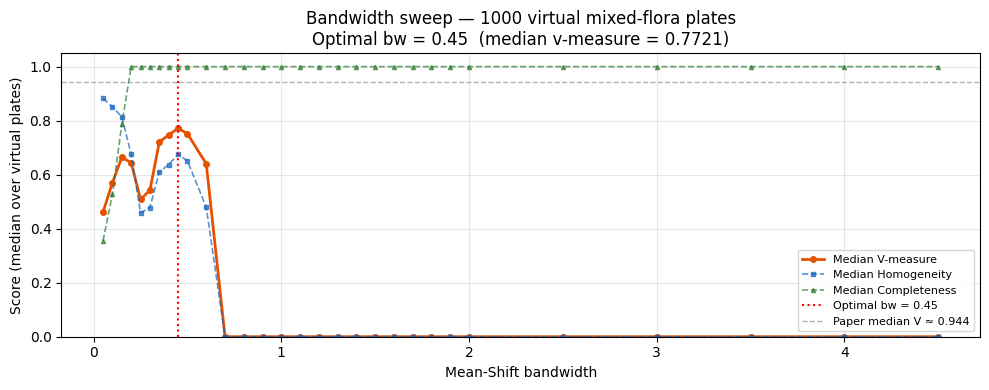

Saved: bw_sweep_curve.png

[4] Diagnosing floor hits in the original auto-bandwidth run ...


  Total test plates       : 270
  Bandwidth floor hits    : 138  (51.1%)
  No-smoothing plates     : 143  (53.0%)
  → These plates got NO benefit from L3 in the original run.
  → With fixed bw=0.45, all plates participate in smoothing.

[5] Re-running Level 3 with fixed bw = 0.4500 ...


  Test plates (fixed bw):   1%|          | 3/270 [00:00<00:10, 25.01it/s]

    Cluster 0: 10 colonies | top-1 idx=25 (conf=0.567)
    Cluster 0: 7 colonies | top-1 idx=17 (conf=0.355)
    Cluster 0: 7 colonies | top-1 idx=17 (conf=0.578)
    Cluster 0: 142 colonies | top-1 idx=26 (conf=0.792)


  Test plates (fixed bw):   2%|▏         | 6/270 [00:01<00:50,  5.26it/s]

...

    Cluster 0: 4 colonies | top-1 idx=12 (conf=0.757)
    Cluster 0: 3 colonies | top-1 idx=12 (conf=0.816)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.667)
    Cluster 0: 4 colonies | top-1 idx=12 (conf=0.513)
    Cluster 0: 7 colonies | top-1 idx=12 (conf=0.792)
    Cluster 0: 2 colonies | top-1 idx=12 (conf=0.866)
    Cluster 0: 5 colonies | top-1 idx=12 (conf=0.851)


  Test plates (fixed bw):  99%|█████████▉| 267/270 [00:24<00:00, 34.30it/s]

    Cluster 0: 3 colonies | top-1 idx=12 (conf=0.577)
    Cluster 0: 6 colonies | top-1 idx=12 (conf=0.888)
    Cluster 0: 3 colonies | top-1 idx=12 (conf=0.758)
    Cluster 0: 2 colonies | top-1 idx=12 (conf=0.753)
    Cluster 0: 2 colonies | top-1 idx=12 (conf=0.863)
    Cluster 0: 3 colonies | top-1 idx=12 (conf=0.926)
    Cluster 0: 2 colonies | top-1 idx=12 (conf=0.888)
    Cluster 0: 2 colonies | top-1 idx=12 (conf=0.838)
    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.907)
    Cluster 1: 1 colonies | top-1 idx=12 (conf=0.842)


  Test plates (fixed bw): 100%|██████████| 270/270 [00:24<00:00, 10.86it/s]


    Cluster 0: 1 colonies | top-1 idx=12 (conf=0.885)

[6] Results comparison

  ┌──────────┬────────────────────────────────┬────────────────────────────────┐
  │          │   Auto-bw (estimate_bw/plate)  │   Fixed-bw (optimal global)    │
  │          ├──────────┬──────────┬──────────┼──────────┬──────────┬──────────┤
  │          │  L2 (%)  │  L3 (%)  │    Δ     │  L2 (%)  │  L3 (%)  │    Δ     │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Top-1   │   79.26  │   88.34  │   +9.09  │   79.26  │   89.45  │  +10.19  │
  │  Top-2   │   90.41  │   95.16  │   +4.75  │   90.41  │   95.77  │   +5.36  │
  │  Top-3   │   94.59  │   96.50  │   +1.91  │   94.59  │   96.47  │   +1.87  │
  └──────────┴──────────┴──────────┴──────────┴──────────┴──────────┴──────────┘

  Net L3 gain from bandwidth fix:
    Top-1: +1.11 pp  ▲
    Top-2: +0.61 pp  ▲
    Top-3: -0.04 pp  ≈


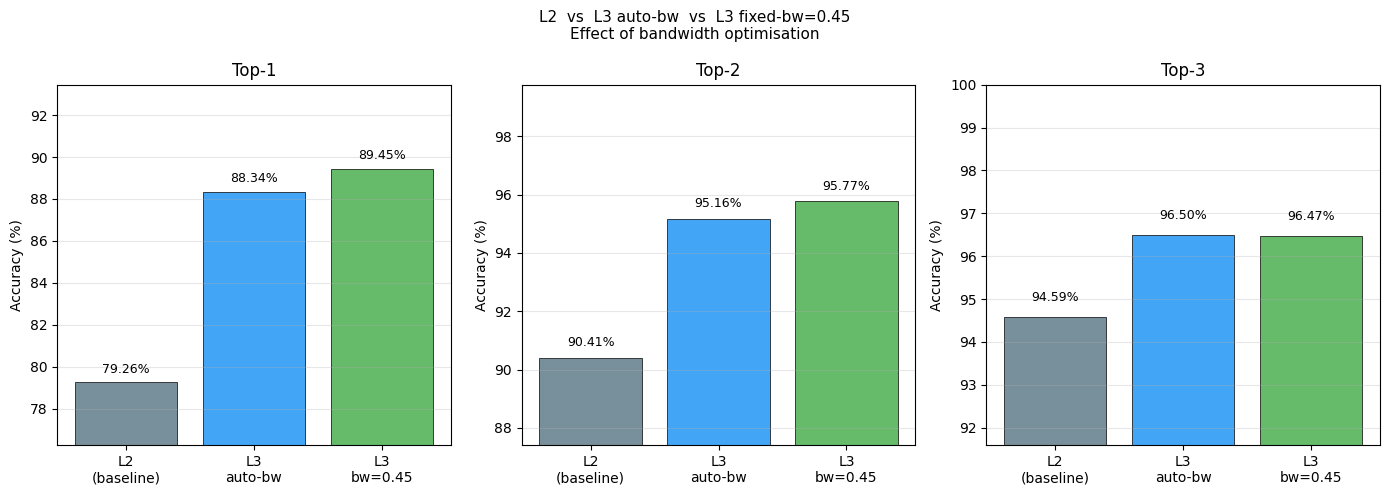


Saved: bw_accuracy_comparison.png


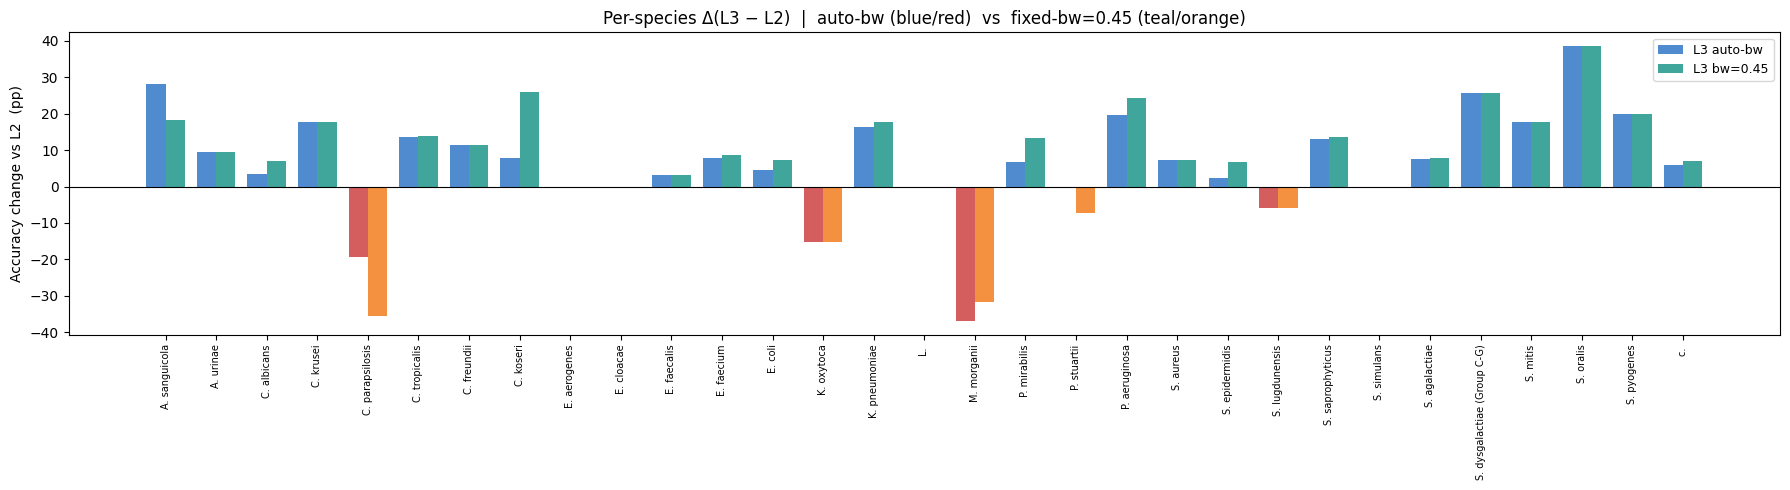

Saved: bw_per_species_delta.png


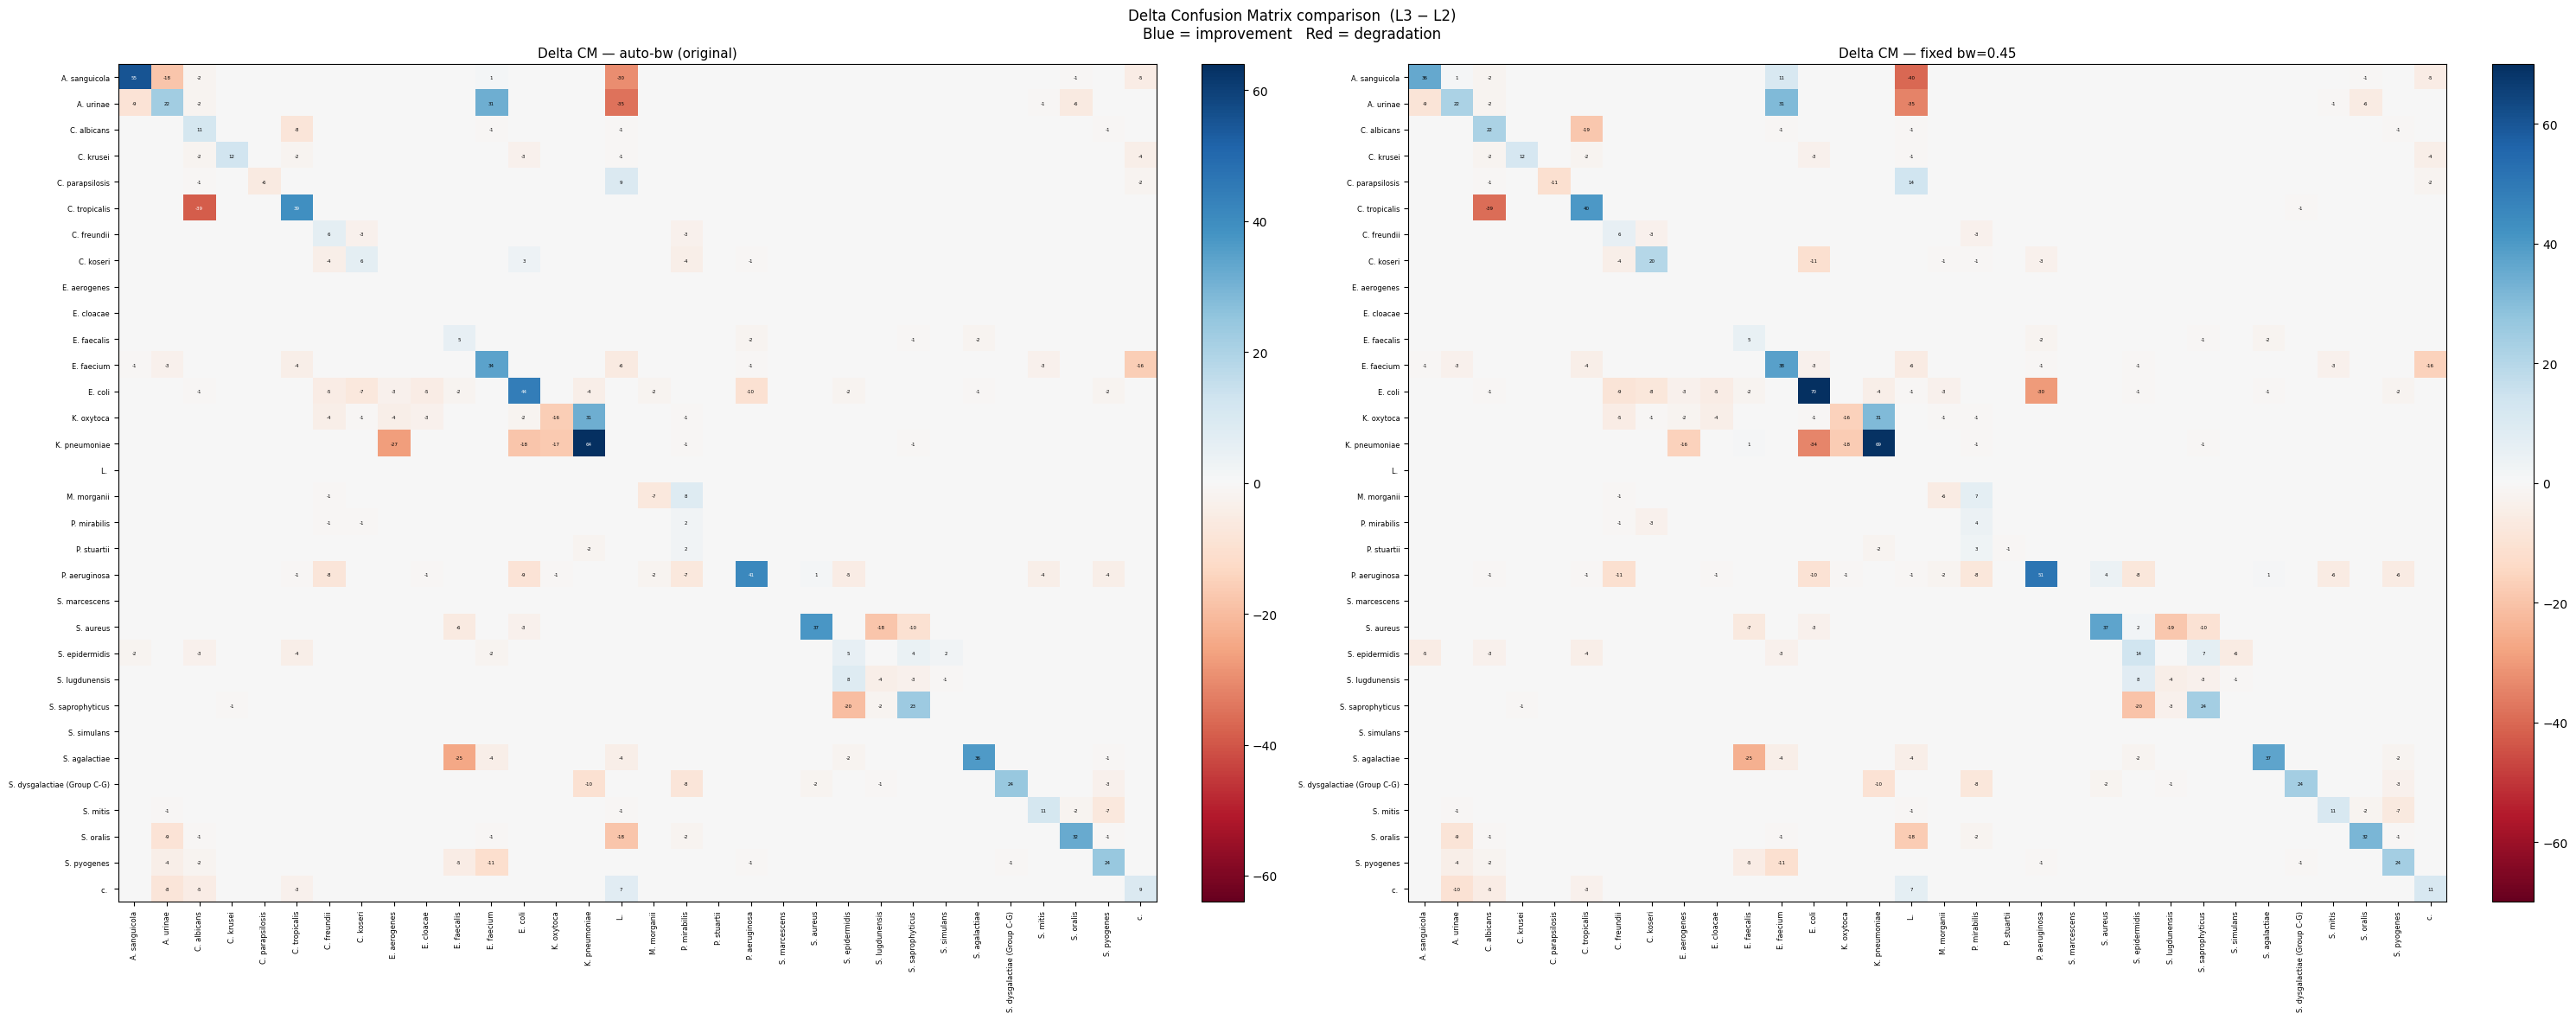

Saved: bw_delta_cm_comparison.png


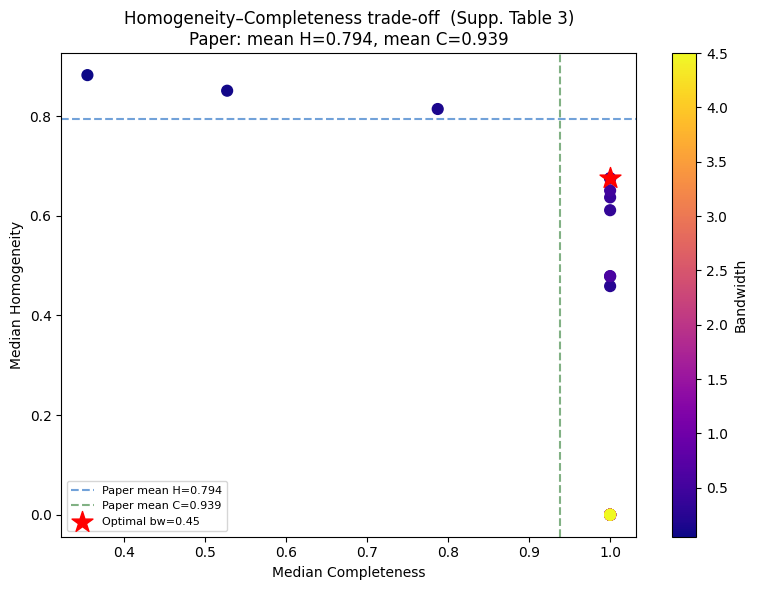

Saved: bw_hc_tradeoff.png

BANDWIDTH OPTIMISATION — COMPLETE
  Virtual plates used   : 1000
  Bandwidth values swept: 30
  Optimal bandwidth     : 0.4500
  Median v-measure      : 0.7721  (paper target ≈ 0.944 median)
  No-smoothing plates eliminated: 143/270 (53.0%)

  Accuracy results:
    Top-1:  auto-bw=88.34%  →  fixed-bw=89.45%  (+1.11 pp) ▲
    Top-2:  auto-bw=95.16%  →  fixed-bw=95.77%  (+0.61 pp) ▲
    Top-3:  auto-bw=96.50%  →  fixed-bw=96.47%  (-0.04 pp) ≈

  Plots saved to: /content/drive/MyDrive/TFG/resultados_entrenamiento/level3_eval


In [ ]:
# ==============================================================================
# BANDWIDTH OPTIMISATION FOR MEAN-SHIFT  (paper Section "Clustering", Supp. Table 3)
# ------------------------------------------------------------------------------
# This cell MUST run after the Level 3 evaluation cell.
# It assumes the following are already in memory:
#   - single_cnn, siamese_cnn, DEVICE
#   - VAL_PLATES, TRAIN_PLATES, TEST_PLATES
#   - plate_to_colonies  (test plates → colonies)
#   - get_pIDv_batch(), get_embeddings_batch(), smooth_pIDv()
#   - topk_acc_from_scores()
#   - IDX_TO_SPECIES, SPECIES_TO_IDX, N_CLASSES, short_labels
#   - metrics  (dict with L2_top1/2/3, L3_top1/2/3 from original run)
#   - all_gt, all_l2_pred, all_l3_pred  (from original run)
#   - delta_cm  (delta confusion matrix from original run)
#   - METADATA_PATH, DATASET_PATH, EVAL_OUTPUT_DIR
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth as _estimate_bw
from sklearn.metrics import homogeneity_completeness_v_measure
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import random, json, os

print('=' * 65)
print('BANDWIDTH OPTIMISATION — replicating paper Supp. Table 3')
print('=' * 65)


# ==============================================================================
# STEP 1 — Build embedding matrix for every VALIDATION plate
#           (virtual plates are constructed from val, not test, to avoid leakage)
# ==============================================================================
print('\n[1] Extracting Siamese embeddings for validation plates ...')

with open(METADATA_PATH) as f:
    _meta = json.load(f)

val_plate_to_colonies = defaultdict(list)
for fname, info in _meta['patch_list'].items():
    pid = info['plate_n']
    if pid in VAL_PLATES:
        gt_str = info['species']
        if gt_str in SPECIES_TO_IDX:
            val_plate_to_colonies[pid].append({
                'path'   : os.path.join(DATASET_PATH, info['filename']),
                'gt_idx' : SPECIES_TO_IDX[gt_str],
                'gt_str' : gt_str,
            })

print(f'  Val plates found : {len(val_plate_to_colonies)}')

val_plate_embeddings = {}

for pid, cols in tqdm(val_plate_to_colonies.items(), desc='  Embedding val plates'):
    paths = [c['path'] for c in cols]
    if not paths:
        continue
    embs = get_embeddings_batch(paths, siamese_cnn, DEVICE)
    val_plate_embeddings[pid] = {
        'embeddings' : embs,
        'gt_indices' : np.array([c['gt_idx'] for c in cols]),
        'species_set': set(c['gt_str'] for c in cols),
    }

print(f'  Plates embedded  : {len(val_plate_embeddings)}')


# ==============================================================================
# STEP 2 — Generate virtual mixed-flora plates
#           Paper: 1000 plates, up to 3 strains per plate
# ==============================================================================
print('\n[2] Generating virtual mixed-flora plates ...')

N_VIRTUAL   = 1000
MAX_STRAINS = 3
rng         = random.Random(42)
plate_ids_val = list(val_plate_embeddings.keys())

virtual_plates = []
attempts = 0
while len(virtual_plates) < N_VIRTUAL and attempts < N_VIRTUAL * 20:
    attempts += 1
    n_strains = rng.randint(2, MAX_STRAINS)
    sampled   = rng.sample(plate_ids_val, k=min(n_strains, len(plate_ids_val)))

    # Require genuinely different species across sampled plates
    all_species = set().union(*[val_plate_embeddings[p]['species_set'] for p in sampled])
    if len(all_species) < 2:
        continue

    emb_parts, label_parts = [], []
    for label_idx, pid in enumerate(sampled):
        e = val_plate_embeddings[pid]['embeddings']
        emb_parts.append(e)
        label_parts.extend([label_idx] * len(e))

    virtual_plates.append({
        'embeddings': np.vstack(emb_parts),
        'labels'    : np.array(label_parts),
    })

print(f'  Virtual plates generated: {len(virtual_plates)}  '
      f'(target {N_VIRTUAL}, attempts {attempts})')
if len(virtual_plates) < N_VIRTUAL:
    print(f'  ⚠  Only {len(virtual_plates)} generated — '
          f'few val plates per species. Continuing with available plates.')


# ==============================================================================
# STEP 3 — Sweep bandwidth  →  pick the one that maximises median v-measure
#           Paper criterion (Supp. Note 3): maximise MEDIAN v-measure
# ==============================================================================
print('\n[3] Sweeping bandwidth candidates ...')

BW_CANDIDATES = np.round(np.concatenate([
    np.arange(0.05, 0.50, 0.05),
    np.arange(0.50, 2.00, 0.10),
    np.arange(2.00, 5.00, 0.50),
]), 4)

sweep_results = {}

for bw in tqdm(BW_CANDIDATES, desc='  bandwidth sweep'):
    v_scores, h_scores, c_scores = [], [], []
    for vp in virtual_plates:
        try:
            ms   = MeanShift(bandwidth=bw, bin_seeding=True, n_jobs=1)
            pred = ms.fit_predict(vp['embeddings'])
            if len(set(pred)) < 2:
                h_scores.append(0.0); c_scores.append(1.0); v_scores.append(0.0)
            else:
                h, c, v = homogeneity_completeness_v_measure(vp['labels'], pred)
                h_scores.append(h); c_scores.append(c); v_scores.append(v)
        except Exception:
            pass

    if v_scores:
        sweep_results[bw] = {
            'median_v' : float(np.median(v_scores)),
            'mean_v'   : float(np.mean(v_scores)),
            'std_v'    : float(np.std(v_scores)),
            'median_h' : float(np.median(h_scores)),
            'median_c' : float(np.median(c_scores)),
        }

OPTIMAL_BW  = max(sweep_results, key=lambda b: sweep_results[b]['median_v'])
best_stats  = sweep_results[OPTIMAL_BW]

print(f'\n  ✓ Optimal bandwidth : {OPTIMAL_BW:.4f}')
print(f'    median v-measure  : {best_stats["median_v"]:.4f}  (paper target ≈ 0.944)')
print(f'    median homogeneity: {best_stats["median_h"]:.4f}  (paper mean = 0.794)')
print(f'    median completeness:{best_stats["median_c"]:.4f}  (paper mean = 0.939)')

# Sweep curve plot
bw_vals = sorted(sweep_results.keys())
mv_vals = [sweep_results[b]['median_v'] for b in bw_vals]
mh_vals = [sweep_results[b]['median_h'] for b in bw_vals]
mc_vals = [sweep_results[b]['median_c'] for b in bw_vals]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bw_vals, mv_vals, 'o-',  color='#E65100', lw=2, ms=4, label='Median V-measure')
ax.plot(bw_vals, mh_vals, 's--', color='#1565C0', lw=1.2, ms=3, alpha=0.7,
        label='Median Homogeneity')
ax.plot(bw_vals, mc_vals, '^--', color='#2E7D32', lw=1.2, ms=3, alpha=0.7,
        label='Median Completeness')
ax.axvline(OPTIMAL_BW, color='red', ls=':', lw=1.5,
           label=f'Optimal bw = {OPTIMAL_BW:.2f}')
ax.axhline(0.944, color='grey', ls='--', lw=1, alpha=0.6,
           label='Paper median V ≈ 0.944')
ax.set_xlabel('Mean-Shift bandwidth')
ax.set_ylabel('Score (median over virtual plates)')
ax.set_title(f'Bandwidth sweep — {len(virtual_plates)} virtual mixed-flora plates\n'
             f'Optimal bw = {OPTIMAL_BW:.2f}  '
             f'(median v-measure = {best_stats["median_v"]:.4f})')
ax.legend(fontsize=8); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'bw_sweep_curve.png'), dpi=150)
plt.show()
print('Saved: bw_sweep_curve.png')


# ==============================================================================
# STEP 4 — Diagnose floor hits in original auto-bandwidth approach
# ==============================================================================
print('\n[4] Diagnosing floor hits in the original auto-bandwidth run ...')

floor_hits, no_smooth = 0, 0
plate_list_test = list(plate_to_colonies.items())
total_test_plates = len(plate_list_test)

for plate_id, colonies in tqdm(plate_list_test, desc='  Floor-hit scan', leave=False):
    paths = [c['path'] for c in colonies]
    if not paths:
        continue
    embs = get_embeddings_batch(paths, siamese_cnn, DEVICE)
    try:
        bw_auto = _estimate_bw(embs, quantile=0.2)
    except Exception:
        bw_auto = 0.0
    if bw_auto <= 0.001:
        floor_hits += 1
    # Does auto-bw clustering produce N clusters = N colonies?
    try:
        pred_auto = MeanShift(bandwidth=max(bw_auto, 0.001),
                              bin_seeding=True).fit_predict(embs)
        if len(set(pred_auto)) == len(embs):
            no_smooth += 1
    except Exception:
        no_smooth += 1

print(f'  Total test plates       : {total_test_plates}')
print(f'  Bandwidth floor hits    : {floor_hits}  '
      f'({100*floor_hits/total_test_plates:.1f}%)')
print(f'  No-smoothing plates     : {no_smooth}  '
      f'({100*no_smooth/total_test_plates:.1f}%)')
print(f'  → These plates got NO benefit from L3 in the original run.')
print(f'  → With fixed bw={OPTIMAL_BW:.2f}, all plates participate in smoothing.')


# ==============================================================================
# STEP 5 — Re-run Level 3 with the FIXED optimal bandwidth
# ==============================================================================
print(f'\n[5] Re-running Level 3 with fixed bw = {OPTIMAL_BW:.4f} ...')

def cluster_with_fixed_bw(embeddings: np.ndarray, bandwidth: float) -> np.ndarray:
    """Mean-Shift with a globally-optimised fixed bandwidth."""
    if len(embeddings) == 1:
        return np.array([0])
    try:
        return MeanShift(bandwidth=bandwidth,
                         bin_seeding=True, n_jobs=1).fit_predict(embeddings).astype(int)
    except Exception:
        return np.zeros(len(embeddings), dtype=int)


all_gt_bw, all_l2_pred_bw, all_l3_pred_bw = [], [], []
all_pIDv_bw, all_sIDv_bw = [], []
cluster_hom_bw, cluster_comp_bw, cluster_vm_bw = [], [], []

for plate_id, colonies in tqdm(plate_list_test, desc='  Test plates (fixed bw)'):
    paths  = [c['path']   for c in colonies]
    labels = [c['gt_idx'] for c in colonies]
    gts    = [c['gt_str'] for c in colonies]
    if not paths:
        continue

    pIDv_p = get_pIDv_batch(paths, single_cnn, DEVICE)
    embs_p = get_embeddings_batch(paths, siamese_cnn, DEVICE)
    clst_p = cluster_with_fixed_bw(embs_p, OPTIMAL_BW)
    sIDv_p = smooth_pIDv(pIDv_p, clst_p)

    all_gt_bw.extend(labels)
    all_l2_pred_bw.extend(np.argmax(pIDv_p, axis=1).tolist())
    all_l3_pred_bw.extend(np.argmax(sIDv_p, axis=1).tolist())
    all_pIDv_bw.append(pIDv_p)
    all_sIDv_bw.append(sIDv_p)

    if len(set(gts)) > 1 and len(set(clst_p)) > 1:
        h, c, v = homogeneity_completeness_v_measure(gts, clst_p)
        cluster_hom_bw.append(h); cluster_comp_bw.append(c); cluster_vm_bw.append(v)

all_gt_bw      = np.array(all_gt_bw)
all_l2_pred_bw = np.array(all_l2_pred_bw)
all_l3_pred_bw = np.array(all_l3_pred_bw)
pIDv_mat_bw    = np.vstack(all_pIDv_bw)
sIDv_mat_bw    = np.vstack(all_sIDv_bw)

metrics_bw = {}
for k in (1, 2, 3):
    metrics_bw[f'L2_top{k}'] = topk_acc_from_scores(all_gt_bw, pIDv_mat_bw, k)
    metrics_bw[f'L3_top{k}'] = topk_acc_from_scores(all_gt_bw, sIDv_mat_bw, k)


# ==============================================================================
# STEP 6 — Comparison table
# ==============================================================================
print('\n[6] Results comparison')
print()
print('  ┌──────────┬────────────────────────────────┬────────────────────────────────┐')
print('  │          │   Auto-bw (estimate_bw/plate)  │   Fixed-bw (optimal global)    │')
print('  │          ├──────────┬──────────┬──────────┼──────────┬──────────┬──────────┤')
print('  │          │  L2 (%)  │  L3 (%)  │    Δ     │  L2 (%)  │  L3 (%)  │    Δ     │')
print('  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤')
for k in (1, 2, 3):
    l2o = metrics[f'L2_top{k}'];    l3o = metrics[f'L3_top{k}'];    do = l3o - l2o
    l2b = metrics_bw[f'L2_top{k}']; l3b = metrics_bw[f'L3_top{k}']; db = l3b - l2b
    print(f'  │  Top-{k}   │  {l2o:6.2f}  │  {l3o:6.2f}  │  {do:+6.2f}  '
          f'│  {l2b:6.2f}  │  {l3b:6.2f}  │  {db:+6.2f}  │')
print('  └──────────┴──────────┴──────────┴──────────┴──────────┴──────────┴──────────┘')
print()
print('  Net L3 gain from bandwidth fix:')
for k in (1, 2, 3):
    gain = metrics_bw[f'L3_top{k}'] - metrics[f'L3_top{k}']
    sign = '▲' if gain > 0.05 else ('▼' if gain < -0.05 else '≈')
    print(f'    Top-{k}: {gain:+.2f} pp  {sign}')


# ==============================================================================
# STEP 7 — Visualisation plots
# ==============================================================================

# Plot A: Accuracy bars — 3 conditions
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ki, k in enumerate((1, 2, 3)):
    ax  = axes[ki]
    l2  = metrics[f'L2_top{k}']
    l3o = metrics[f'L3_top{k}']
    l3b = metrics_bw[f'L3_top{k}']
    vals = [l2, l3o, l3b]
    cols = ['#78909C', '#42A5F5', '#66BB6A']
    bars = ax.bar(['L2\n(baseline)', 'L3\nauto-bw', f'L3\nbw={OPTIMAL_BW:.2f}'],
                  vals, color=cols, edgecolor='k', lw=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Top-{k}', fontsize=12)
    ax.set_ylabel('Accuracy (%)')
    ymin = max(0, min(vals) - 3)
    ax.set_ylim(ymin, min(100, max(vals) + 4))
    ax.grid(axis='y', alpha=0.3)
plt.suptitle(f'L2  vs  L3 auto-bw  vs  L3 fixed-bw={OPTIMAL_BW:.2f}\n'
             'Effect of bandwidth optimisation', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'bw_accuracy_comparison.png'), dpi=150)
plt.show()
print('\nSaved: bw_accuracy_comparison.png')

# Plot B: Per-species delta side-by-side
delta_auto, delta_fixed, valid_idx_sp = [], [], []
for cls_idx in range(N_CLASSES):
    mask = (all_gt == cls_idx)
    if mask.sum() == 0:
        continue
    l2_acc = 100.0 * (all_l2_pred[mask]    == cls_idx).mean()
    l3_a   = 100.0 * (all_l3_pred[mask]    == cls_idx).mean()
    mask_b = (all_gt_bw == cls_idx)
    l3_b   = 100.0 * (all_l3_pred_bw[mask_b] == cls_idx).mean() if mask_b.sum() > 0 else l2_acc
    delta_auto.append(l3_a - l2_acc)
    delta_fixed.append(l3_b - l2_acc)
    valid_idx_sp.append(cls_idx)

x, w = np.arange(len(valid_idx_sp)), 0.38
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - w/2, delta_auto,  w, alpha=0.75, label='L3 auto-bw',
       color=['#1565C0' if d >= 0 else '#C62828' for d in delta_auto])
ax.bar(x + w/2, delta_fixed, w, alpha=0.75, label=f'L3 bw={OPTIMAL_BW:.2f}',
       color=['#00897B' if d >= 0 else '#EF6C00' for d in delta_fixed])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([short_labels[i] for i in valid_idx_sp], rotation=90, fontsize=7)
ax.set_ylabel('Accuracy change vs L2  (pp)')
ax.set_title('Per-species Δ(L3 − L2)  |  auto-bw (blue/red)  vs  '
             f'fixed-bw={OPTIMAL_BW:.2f} (teal/orange)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'bw_per_species_delta.png'), dpi=150)
plt.show()
print('Saved: bw_per_species_delta.png')

# Plot C: Delta CM comparison
cm_l2_bw = confusion_matrix(all_gt_bw, all_l2_pred_bw, labels=list(range(N_CLASSES)))
cm_l3_bw = confusion_matrix(all_gt_bw, all_l3_pred_bw, labels=list(range(N_CLASSES)))
delta_bw  = cm_l3_bw - cm_l2_bw

fig, axes = plt.subplots(1, 2, figsize=(30, 12))
for ax, dcm, title in [
    (axes[0], delta_cm, 'Delta CM — auto-bw (original)'),
    (axes[1], delta_bw, f'Delta CM — fixed bw={OPTIMAL_BW:.2f}'),
]:
    vmax_d = max(abs(dcm).max(), 1)
    im = ax.imshow(dcm, cmap='RdBu', vmin=-vmax_d, vmax=vmax_d, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(short_labels, rotation=90, fontsize=6)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(short_labels, fontsize=6)
    ax.set_title(title, fontsize=11)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            if dcm[i, j] != 0:
                ax.text(j, i, str(dcm[i, j]), ha='center', va='center', fontsize=4,
                        color='white' if abs(dcm[i, j]) > vmax_d * 0.6 else 'black')
plt.suptitle('Delta Confusion Matrix comparison  (L3 − L2)\n'
             'Blue = improvement   Red = degradation', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'bw_delta_cm_comparison.png'), dpi=120)
plt.show()
print('Saved: bw_delta_cm_comparison.png')

# Plot D: H–C trade-off scatter
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    [sweep_results[b]['median_c'] for b in bw_vals],
    [sweep_results[b]['median_h'] for b in bw_vals],
    c=bw_vals, cmap='plasma', s=60, zorder=3
)
plt.colorbar(sc, ax=ax, label='Bandwidth')
ax.axhline(0.79407, color='#1565C0', ls='--', alpha=0.6, label='Paper mean H=0.794')
ax.axvline(0.93863, color='#2E7D32', ls='--', alpha=0.6, label='Paper mean C=0.939')
opt_h = sweep_results[OPTIMAL_BW]['median_h']
opt_c = sweep_results[OPTIMAL_BW]['median_c']
ax.scatter([opt_c], [opt_h], s=250, marker='*', color='red', zorder=5,
           label=f'Optimal bw={OPTIMAL_BW:.2f}')
ax.set_xlabel('Median Completeness'); ax.set_ylabel('Median Homogeneity')
ax.set_title('Homogeneity–Completeness trade-off  (Supp. Table 3)\n'
             'Paper: mean H=0.794, mean C=0.939')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'bw_hc_tradeoff.png'), dpi=150)
plt.show()
print('Saved: bw_hc_tradeoff.png')


# ==============================================================================
# FINAL SUMMARY
# ==============================================================================
print('\n' + '=' * 65)
print('BANDWIDTH OPTIMISATION — COMPLETE')
print('=' * 65)
print(f'  Virtual plates used   : {len(virtual_plates)}')
print(f'  Bandwidth values swept: {len(BW_CANDIDATES)}')
print(f'  Optimal bandwidth     : {OPTIMAL_BW:.4f}')
print(f'  Median v-measure      : {best_stats["median_v"]:.4f}'
      f'  (paper target ≈ 0.944 median)')
print(f'  No-smoothing plates eliminated: '
      f'{no_smooth}/{total_test_plates} ({100*no_smooth/total_test_plates:.1f}%)')
print()
print('  Accuracy results:')
for k in (1, 2, 3):
    l3o  = metrics[f'L3_top{k}']
    l3b  = metrics_bw[f'L3_top{k}']
    gain = l3b - l3o
    arrow = '▲' if gain > 0.05 else ('▼' if gain < -0.05 else '≈')
    print(f'    Top-{k}:  auto-bw={l3o:.2f}%  →  fixed-bw={l3b:.2f}%  '
          f'({gain:+.2f} pp) {arrow}')
print()
print(f'  Plots saved to: {EVAL_OUTPUT_DIR}')